# MS3SEG VentiMorph-RelNet V2.7 — Fold-4 Training

This notebook trains the **same frozen V2.7 architecture and optimization
protocol used for Fold 4**, but on **Fold 4**.

Important rules:

- training starts from scratch for Fold 4;
- Fold-4 model weights are never loaded;
- the previously saved `patient_level_5fold_split.csv` is reused so the
  exact same 80-development / 20-locked-test partition is preserved;
- the 20 locked-test patients are never evaluated;
- a 10-epoch stability pilot runs first;
- the same run automatically resumes and continues to a maximum of
  60 total epochs;
- best, weighted-best, normal-WMH-best and resumable checkpoints are saved.

Required Kaggle inputs:

1. `MS3SEG`
2. `ms3seg-v27-best-checkpoint`

The second input is used only to recover the saved five-fold split file.
It is **not** used to initialize Fold-4 model weights.

## Kaggle instructions

1. Add the `MS3SEG` dataset.
2. Add the `ms3seg-v27-best-checkpoint` private dataset.
3. In **Settings**, choose a **T4 GPU**.
4. Run the notebook with **Run All**.
5. Do not enable locked-test evaluation.
6. After training finishes, download:

`/kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip`

## VentiMorph-RelNet v2.3 — stable DataLoader and automatic resume

The previous full run was learning correctly, but execution was interrupted
while waiting for a multiprocessing DataLoader worker.

This version keeps the successful v2.2 model and loss configuration, while
adding only stability and recovery changes:

- `num_workers=0`;
- `persistent_workers=False`;
- `pin_memory=False`;
- a `last_checkpoint.pt` file after every completed epoch;
- automatic resume from `last_checkpoint.pt`;
- fallback warm start from `best_model.pt`;
- emergency checkpoint saving when a `KeyboardInterrupt` occurs.

No model architecture or loss-performance setting has been changed.

## V2.2 full training

The ten-epoch conservative pilot passed successfully.

Best pilot epoch: **10**

- Ventricle Dice: **0.7246**
- Normal-WMH Dice: **0.5551**
- Abnormal-WMH Dice: **0.7236**
- Mean foreground Dice: **0.6678**
- WMH-focused selection score: **0.6564**

This notebook is now configured for the full 80-epoch Fold-4 run.
The pilot is disabled, and the final verification cell runs only after
full training has completed.

## VentiMorph-RelNet v2.2 — conservative improvement

This version is built from the previously successful Fold-4 notebook rather
than the unstable v2.1 pilot.

It removes EMA validation, ventricle curriculum guidance, modality dropout,
and aggressive WMH-loss weighting. Only three controlled changes are used:

1. equal slice-sampling priority for normal and abnormal WMH;
2. a gently ramped normal-WMH focal-Tversky term;
3. a low-weight normal-versus-abnormal WMH confusion penalty.

The architecture, optimizer, mixed precision, and stable validation procedure
remain the same as the successful baseline.

## Full-training configuration

The three-epoch smoke test completed successfully:

- one-batch forward/backward dry run passed;
- all loss values were finite;
- the checkpoint was saved;
- validation metrics were produced.

This notebook is now configured for the **80-epoch fold-4 full training run**.

Locked-test evaluation and ablation experiments remain disabled. Do not enable them until the full training checkpoint has been created.

## Correction applied after the smoke-test run

The submitted smoke test reached the training loop but stopped because
`binary_cross_entropy` was applied to sigmoid probabilities inside mixed
precision. PyTorch blocks this operation under autocast.

This corrected notebook now:

- uses `binary_cross_entropy_with_logits` for ventricle supervision;
- keeps Dice loss on sigmoid probabilities;
- uses the current `torch.amp` mixed-precision API;
- preserves the three-epoch smoke-test configuration.

## Immediate next step

Run the notebook from the beginning with a **T4 GPU**. The notebook is already
configured for a three-epoch smoke test:

```python
RUN_SMOKE_TEST = True
RUN_FULL_TRAINING = False
```

After the smoke test succeeds, change them to:

```python
RUN_SMOKE_TEST = False
RUN_FULL_TRAINING = True
```

Keep locked-test evaluation and ablations disabled until full training finishes.

## Status of the submitted run

The submitted notebook successfully:

- detected all **100 patients**;
- matched FLAIR, registered T1, registered T2, and all three masks;
- confirmed matching shapes and affine matrices;
- created **64 training, 16 validation, and 20 locked-test patients** for fold 4;
- measured the complete four-class voxel distribution.

The model forward pass failed because the selected Tesla P100 GPU was incompatible with the installed PyTorch CUDA kernels. Consequently, no training, validation, ablation, or test performance was produced.

In [1]:
# Kaggle dependency cell:
# !pip install -q nibabel surface-distance

In [2]:
from __future__ import annotations

import os, re, gc, json, math, random, warnings
from dataclasses import dataclass, asdict
from functools import lru_cache
from pathlib import Path
from typing import List, Tuple, Literal

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.model_selection import train_test_split, StratifiedKFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything()

# ------------------------------------------------------------------
# GPU compatibility check
# ------------------------------------------------------------------
GPU_COMPATIBLE = False
GPU_MESSAGE = ""

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    capability = torch.cuda.get_device_capability(0)
    required_arch = f"sm_{capability[0]}{capability[1]}"
    compiled_arches = set(torch.cuda.get_arch_list())

    GPU_COMPATIBLE = required_arch in compiled_arches

    if GPU_COMPATIBLE:
        DEVICE = torch.device("cuda")
        GPU_MESSAGE = (
            f"Compatible GPU: {gpu_name}; capability={required_arch}; "
            f"PyTorch architectures={sorted(compiled_arches)}"
        )
    else:
        DEVICE = torch.device("cpu")
        GPU_MESSAGE = (
            f"Incompatible GPU: {gpu_name}; capability={required_arch}; "
            f"this PyTorch build supports {sorted(compiled_arches)}. "
            "For training, select a T4 GPU or another supported GPU in "
            "Kaggle Settings, restart the session, and Run All."
        )
else:
    DEVICE = torch.device("cpu")
    GPU_MESSAGE = (
        "CUDA is unavailable. Enable a compatible Kaggle GPU before training."
    )

print("Selected device:", DEVICE)
print(GPU_MESSAGE)

Selected device: cuda
Compatible GPU: Tesla T4; capability=sm_75; PyTorch architectures=['sm_100', 'sm_120', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']


## Important GPU correction

The previous run selected a **Tesla P100 (`sm_60`)**, but the installed PyTorch build supported `sm_70` and newer CUDA architectures.

Before model training:

1. Open **Kaggle Notebook → Settings**.
2. Select **T4 GPU** or another GPU supported by the architecture list printed above.
3. Restart the session.
4. Run the notebook from the beginning.

The corrected notebook can continue dataset auditing on CPU, but it blocks training until a compatible GPU is active.

In [3]:
def discover_ms3seg_root():
    preferred_candidates = [
        Path(
            "/kaggle/input/datasets/saifsamiul/ms3seg/MS3SEG"
        ),
        Path(
            "/kaggle/input/ms3seg/MS3SEG"
        ),
        Path(
            "/kaggle/input/ms3seg"
        ),
    ]

    required_directories = {
        "MS_100_patient_preprocessed",
        "MS_100_patient_masks",
    }

    for candidate in preferred_candidates:
        if (
            candidate.exists()
            and required_directories.issubset({
                path.name
                for path in candidate.iterdir()
                if path.is_dir()
            })
        ):
            return candidate

    input_root = Path(
        "/kaggle/input"
    )

    if input_root.exists():
        for preprocessed_directory in input_root.rglob(
            "MS_100_patient_preprocessed"
        ):
            candidate = (
                preprocessed_directory.parent
            )

            if (
                candidate
                / "MS_100_patient_masks"
            ).exists():
                return candidate

    raise FileNotFoundError(
        "MS3SEG dataset root was not found. Add the same MS3SEG dataset "
        "through Kaggle Add Input and verify that it contains "
        "MS_100_patient_preprocessed and MS_100_patient_masks."
    )


DATA_ROOT = discover_ms3seg_root()
PREPROCESSED_DIR = (
    DATA_ROOT
    / "MS_100_patient_preprocessed"
)
MASKS_DIR = (
    DATA_ROOT
    / "MS_100_patient_masks"
)
MODEL_INPUT_DIR = (
    DATA_ROOT
    / "MS_100_model_input"
)

OUTPUT_DIR = Path(
    "/kaggle/working/ventimorph_v27_fold4_training"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Dataset root:",
    DATA_ROOT,
)
print(
    "Output directory:",
    OUTPUT_DIR,
)

Dataset root: /kaggle/input/datasets/saifsamiul/ms3seg/MS3SEG
Output directory: /kaggle/working/ventimorph_v27_fold4_training


In [4]:
mask_roots = [p for p in MASKS_DIR.iterdir() if p.is_dir()]
print("Mask roots:", [p.name for p in mask_roots])

def select_mask_root(kind):
    if kind == "vent":
        matches = [p for p in mask_roots if "vent" in p.name.lower()]
    elif kind == "nwmh":
        matches = [p for p in mask_roots
                   if ("nwmh" in p.name.lower() or "normal" in p.name.lower())
                   and "abwmh" not in p.name.lower()
                   and "abnormal" not in p.name.lower()]
    else:
        matches = [p for p in mask_roots
                   if "abwmh" in p.name.lower() or "abnormal" in p.name.lower()]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one {kind} mask root, found {matches}")
    return matches[0]

VENT_ROOT = select_mask_root("vent")
NWMH_ROOT = select_mask_root("nwmh")
ABWMH_ROOT = select_mask_root("abwmh")

Mask roots: ['nWMH_Masks', 'abWMH_Masks', 'Vent_Masks']


In [5]:
def find_unique_file(folder, patterns, description):
    found = []
    for pattern in patterns:
        found.extend(folder.glob(pattern))
    unique = []
    seen = set()
    for p in found:
        if p.is_file() and p not in seen:
            unique.append(p)
            seen.add(p)
    if len(unique) != 1:
        raise FileNotFoundError(
            f"{description}: expected 1 match in {folder}, found {len(unique)}: {unique}"
        )
    return unique[0]

patient_dirs = sorted(
    p for p in PREPROCESSED_DIR.iterdir()
    if p.is_dir() and re.fullmatch(r"\d{3}", p.name)
)

records = []
for pdir in patient_dirs:
    pid = pdir.name
    records.append({
        "patient_id": pid,
        "flair": str(find_unique_file(
            pdir, [f"{pid}_FLAIR.nii", f"{pid}_FLAIR.nii.gz"], f"{pid} FLAIR")),
        "t1": str(find_unique_file(
            pdir, [f"{pid}_T1WI_reg.nii", f"{pid}_T1WI_reg.nii.gz", "*T1*reg*.nii*"], f"{pid} T1")),
        "t2": str(find_unique_file(
            pdir, [f"{pid}_T2WI_reg.nii", f"{pid}_T2WI_reg.nii.gz", "*T2*reg*.nii*"], f"{pid} T2")),
        "vent": str(find_unique_file(
            VENT_ROOT / pid, [f"{pid}_Vent_Mask.nii", f"{pid}_Vent_Mask.nii.gz", "*Vent*Mask*.nii*"], f"{pid} vent")),
        "nwmh": str(find_unique_file(
            NWMH_ROOT / pid, [f"{pid}_nWMH_Mask.nii", f"{pid}_nWMH_Mask.nii.gz", "*nWMH*Mask*.nii*"], f"{pid} nWMH")),
        "abwmh": str(find_unique_file(
            ABWMH_ROOT / pid, [f"{pid}_abWMH_Mask.nii", f"{pid}_abWMH_Mask.nii.gz", "*abWMH*Mask*.nii*"], f"{pid} abWMH")),
    })

manifest = pd.DataFrame(records).sort_values("patient_id").reset_index(drop=True)
print("Patients:", len(manifest))
display(manifest.head())
if len(manifest) != 100:
    warnings.warn(f"Expected 100 patients, found {len(manifest)}")
manifest.to_csv(OUTPUT_DIR / "patient_manifest.csv", index=False)

Patients: 100


,patient_id,flair,t1,t2,vent,nwmh,abwmh
0,001,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...
1,002,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...
2,003,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...
3,004,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...
4,005,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...,/kaggle/input/datasets/saifsamiul/ms3seg/MS3SE...


In [6]:
audit_rows = []
global_counts = np.zeros(4, dtype=np.int64)
overlaps = dict(vent_nwmh=0, vent_abwmh=0, nwmh_abwmh=0, triple=0)

for _, row in manifest.iterrows():
    imgs = {k: nib.load(row[k], mmap=True)
            for k in ["flair", "t1", "t2", "vent", "nwmh", "abwmh"]}
    shapes = {k: imgs[k].shape for k in imgs}
    same_shape = len(set(shapes.values())) == 1
    affine_ok = all(np.allclose(imgs[k].affine, imgs["flair"].affine, atol=1e-3)
                    for k in imgs)

    raw_masks = {
        key: np.asanyarray(imgs[key].dataobj)
        for key in ["vent", "nwmh", "abwmh"]
    }
    raw_values = {
        key: np.unique(raw_masks[key])
        for key in raw_masks
    }

    def is_two_level_binary_encoding(values):
        values = np.asarray(values)
        return (
            values.size in (1, 2)
            and np.isfinite(values).all()
            and np.isclose(values.min(), 0.0)
            and values.max() >= 0.0
        )

    binary_ok = all(
        is_two_level_binary_encoding(raw_values[key])
        for key in raw_values
    )
    strict_zero_one = all(
        set(np.round(raw_values[key], 8).tolist()).issubset({0.0, 1.0})
        for key in raw_values
    )

    # Convert any positive foreground code, including 255, to one.
    vent = raw_masks["vent"] > 0
    nwmh = raw_masks["nwmh"] > 0
    abwmh = raw_masks["abwmh"] > 0

    ov_vn = int((vent & nwmh).sum())
    ov_va = int((vent & abwmh).sum())
    ov_na = int((nwmh & abwmh).sum())
    ov_tr = int((vent & nwmh & abwmh).sum())
    overlaps["vent_nwmh"] += ov_vn
    overlaps["vent_abwmh"] += ov_va
    overlaps["nwmh_abwmh"] += ov_na
    overlaps["triple"] += ov_tr

    target = np.zeros(vent.shape, dtype=np.uint8)
    target[vent] = 1
    target[nwmh] = 2
    target[abwmh] = 3
    counts = np.bincount(target.ravel(), minlength=4)
    global_counts += counts

    spacing = tuple(float(v) for v in imgs["flair"].header.get_zooms()[:3])
    audit_rows.append({
        "patient_id": row.patient_id,
        "shape": str(shapes["flair"]),
        "spacing_x": spacing[0], "spacing_y": spacing[1], "spacing_z": spacing[2],
        "same_shape": same_shape,
        "affine_ok": affine_ok,
        "binary_masks": binary_ok,
        "strict_zero_one": strict_zero_one,
        "vent_raw_values": str(raw_values["vent"].tolist()),
        "nwmh_raw_values": str(raw_values["nwmh"].tolist()),
        "abwmh_raw_values": str(raw_values["abwmh"].tolist()),
        "vent_voxels": int(vent.sum()),
        "nwmh_voxels": int(nwmh.sum()),
        "abwmh_voxels": int(abwmh.sum()),
        "overlap_vent_nwmh": ov_vn,
        "overlap_vent_abwmh": ov_va,
        "overlap_nwmh_abwmh": ov_na,
        "overlap_triple": ov_tr,
    })

audit = pd.DataFrame(audit_rows)
audit.to_csv(OUTPUT_DIR / "integrity_audit.csv", index=False)
print("All shapes match:", audit.same_shape.all())
print("All affines match:", audit.affine_ok.all())
print("All masks have valid two-level binary encoding:", audit.binary_masks.all())
print("All masks use strict raw {0,1} values:", audit.strict_zero_one.all())
print("Overlap totals:", overlaps)

class_distribution = pd.DataFrame({
    "class_id": range(4),
    "class_name": ["Background", "Ventricle", "Normal_WMH", "Abnormal_WMH"],
    "voxels": global_counts,
    "percentage": 100.0 * global_counts / global_counts.sum(),
})
display(class_distribution)
class_distribution.to_csv(OUTPUT_DIR / "class_distribution.csv", index=False)

All shapes match: True
All affines match: True
All masks have valid two-level binary encoding: True
All masks use strict raw {0,1} values: False
Overlap totals: {'vent_nwmh': 2, 'vent_abwmh': 9, 'nwmh_abwmh': 227, 'triple': 0}


,class_id,class_name,voxels,percentage
0,0,Background,129192863,99.311166
1,1,Ventricle,523012,0.402042
2,2,Normal_WMH,151022,0.116091
3,3,Abnormal_WMH,222063,0.170701


## Mask-encoding diagnostic

Some NIfTI masks may use `{0,255}` or another two-level foreground encoding rather than strict `{0,1}` values. Such masks remain valid after conversion of every positive value to `1`. Any mask containing more than two finite levels is blocked from training.

In [7]:
nonstandard_masks = audit.loc[
    ~audit["strict_zero_one"],
    [
        "patient_id",
        "binary_masks",
        "vent_raw_values",
        "nwmh_raw_values",
        "abwmh_raw_values",
    ],
]

print("Patients with non-{0,1} raw encoding:", len(nonstandard_masks))
display(nonstandard_masks.head(30))

invalid_masks = audit.loc[~audit["binary_masks"]]
if len(invalid_masks) > 0:
    display(invalid_masks[
        [
            "patient_id",
            "vent_raw_values",
            "nwmh_raw_values",
            "abwmh_raw_values",
        ]
    ])
    raise ValueError(
        "At least one mask is not a valid two-level binary encoding. "
        "Inspect the displayed values before training."
    )

print(
    "All masks are valid after converting every positive "
    "foreground code to 1."
)

Patients with non-{0,1} raw encoding: 100


,patient_id,binary_masks,vent_raw_values,nwmh_raw_values,abwmh_raw_values
0,001,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
1,002,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
2,003,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
3,004,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
4,005,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
5,006,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
6,007,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
7,008,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
8,009,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"
9,010,True,"[0.0, 0.9999999997671694]","[0.0, 254.9999999406282]","[0.0, 254.9999999406282]"


All masks are valid after converting every positive foreground code to 1.


In [8]:
patient_stats = audit[
    [
        "patient_id",
        "vent_voxels",
        "nwmh_voxels",
        "abwmh_voxels",
        "spacing_x",
        "spacing_y",
        "spacing_z",
    ]
].copy()

patient_stats["voxel_volume_mm3"] = (
    patient_stats.spacing_x
    * patient_stats.spacing_y
    * patient_stats.spacing_z
)

for name in ["vent", "nwmh", "abwmh"]:
    patient_stats[f"{name}_volume_ml"] = (
        patient_stats[f"{name}_voxels"]
        * patient_stats.voxel_volume_mm3
        / 1000.0
    )


def find_saved_split():
    input_root = Path("/kaggle/input")

    preferred = list(
        input_root.glob(
            "ms3seg-v27-best-checkpoint/**/"
            "patient_level_5fold_split.csv"
        )
    )

    candidates = preferred or list(
        input_root.rglob(
            "patient_level_5fold_split.csv"
        )
    )

    candidates = [
        path
        for path in candidates
        if path.is_file()
    ]

    if not candidates:
        raise FileNotFoundError(
            "patient_level_5fold_split.csv was not found. "
            "Add the ms3seg-v27-best-checkpoint dataset. "
            "Fold 4 must reuse the exact saved split from Fold 0."
        )

    candidates = sorted(
        candidates,
        key=lambda path: (
            "ms3seg-v27-best-checkpoint" in str(path).lower(),
            path.stat().st_size,
        ),
        reverse=True,
    )

    return candidates[0]


SAVED_SPLIT_PATH = find_saved_split()

split_df = pd.read_csv(
    SAVED_SPLIT_PATH,
    dtype={"patient_id": str},
)

split_df["patient_id"] = (
    split_df["patient_id"]
    .astype(str)
    .str.zfill(3)
)

required_columns = {
    "patient_id",
    "fold",
    "role",
}

missing_columns = (
    required_columns
    - set(split_df.columns)
)

if missing_columns:
    raise ValueError(
        "Saved split file is missing columns: "
        f"{sorted(missing_columns)}"
    )

valid_roles = {
    "train",
    "val",
    "test",
}

unknown_roles = (
    set(split_df.role.unique())
    - valid_roles
)

if unknown_roles:
    raise ValueError(
        "Unexpected split roles: "
        f"{sorted(unknown_roles)}"
    )

locked_test_ids_from_split = (
    split_df.loc[
        split_df.role == "test",
        "patient_id",
    ]
    .drop_duplicates()
    .tolist()
)

if len(locked_test_ids_from_split) != 20:
    raise ValueError(
        "Expected 20 locked-test patients in the saved split, "
        f"found {len(locked_test_ids_from_split)}."
    )

for fold_number in range(5):
    train_count = (
        split_df.loc[
            (
                split_df.fold == fold_number
            )
            & (
                split_df.role == "train"
            ),
            "patient_id",
        ]
        .nunique()
    )

    validation_count = (
        split_df.loc[
            (
                split_df.fold == fold_number
            )
            & (
                split_df.role == "val"
            ),
            "patient_id",
        ]
        .nunique()
    )

    if (
        train_count != 64
        or validation_count != 16
    ):
        raise ValueError(
            f"Fold {fold_number} has "
            f"{train_count} training and "
            f"{validation_count} validation patients; "
            "expected 64 and 16."
        )

development_ids = set(
    split_df.loc[
        split_df.role.isin(
            ["train", "val"]
        ),
        "patient_id",
    ]
)

locked_test_ids_set = set(
    locked_test_ids_from_split
)

if development_ids.intersection(
    locked_test_ids_set
):
    raise RuntimeError(
        "Data leakage detected: a locked-test patient "
        "appears in development folds."
    )

split_df.to_csv(
    OUTPUT_DIR / "patient_level_5fold_split.csv",
    index=False,
)

patient_stats.to_csv(
    OUTPUT_DIR / "patient_burden_statistics.csv",
    index=False,
)

print(
    "Saved split loaded from:",
    SAVED_SPLIT_PATH,
)

print(
    "Development patients:",
    len(development_ids),
)

print(
    "Locked test patients:",
    len(locked_test_ids_set),
)

print(
    "Split integrity check passed."
)

Saved split loaded from: /kaggle/input/datasets/saifsoft/ms3seg-v27-best-checkpoint/patient_level_5fold_split.csv
Development patients: 80
Locked test patients: 20
Split integrity check passed.


In [9]:
split_candidates = []
for root in [MODEL_INPUT_DIR, DATA_ROOT]:
    if root.exists():
        for p in root.rglob("*"):
            if (p.is_file()
                and any(t in p.name.lower() for t in ["split", "fold", "train", "val", "test"])
                and p.suffix.lower() in {".csv", ".json", ".txt", ".xlsx"}):
                split_candidates.append(p)
print("Possible official split files:")
for p in split_candidates[:100]:
    print(" -", p)

Possible official split files:


In [10]:
@lru_cache(maxsize=48)
def load_volume(path):
    return np.asarray(nib.load(path, mmap=True).dataobj, dtype=np.float32)

@lru_cache(maxsize=36)
def load_normalized_volume(path):
    arr = load_volume(path).copy()
    finite = np.isfinite(arr)
    nz = finite & (np.abs(arr) > 1e-6)
    if nz.sum() < 100:
        return np.nan_to_num(arr).astype(np.float32)
    low, high = np.percentile(arr[nz], [0.5, 99.5])
    high = max(high, low + 1.0)
    arr = np.clip(arr, low, high)
    arr = (arr - arr[nz].mean()) / (arr[nz].std() + 1e-6)
    arr[~finite] = 0.0
    return arr.astype(np.float32)

@lru_cache(maxsize=48)
def load_binary_mask(path):
    return (load_volume(path) > 0).astype(np.uint8)

def compose_target(row):
    vent = load_binary_mask(row.vent)
    nwmh = load_binary_mask(row.nwmh)
    abwmh = load_binary_mask(row.abwmh)
    target = np.zeros(vent.shape, dtype=np.uint8)
    target[vent > 0] = 1
    target[nwmh > 0] = 2
    target[abwmh > 0] = 3
    return target

@lru_cache(maxsize=120)
def relation_band_volume(vent_path):
    img = nib.load(vent_path, mmap=True)
    vent = np.asarray(img.dataobj) > 0.5
    spacing = img.header.get_zooms()[:2]
    bands = np.zeros_like(vent, dtype=np.uint8)
    for z in range(vent.shape[2]):
        dist = ndimage.distance_transform_edt(~vent[:, :, z], sampling=spacing)
        band = np.full(dist.shape, 2, dtype=np.uint8)
        band[dist <= 10.0] = 1
        band[dist <= 3.0] = 0
        bands[:, :, z] = band
    return bands

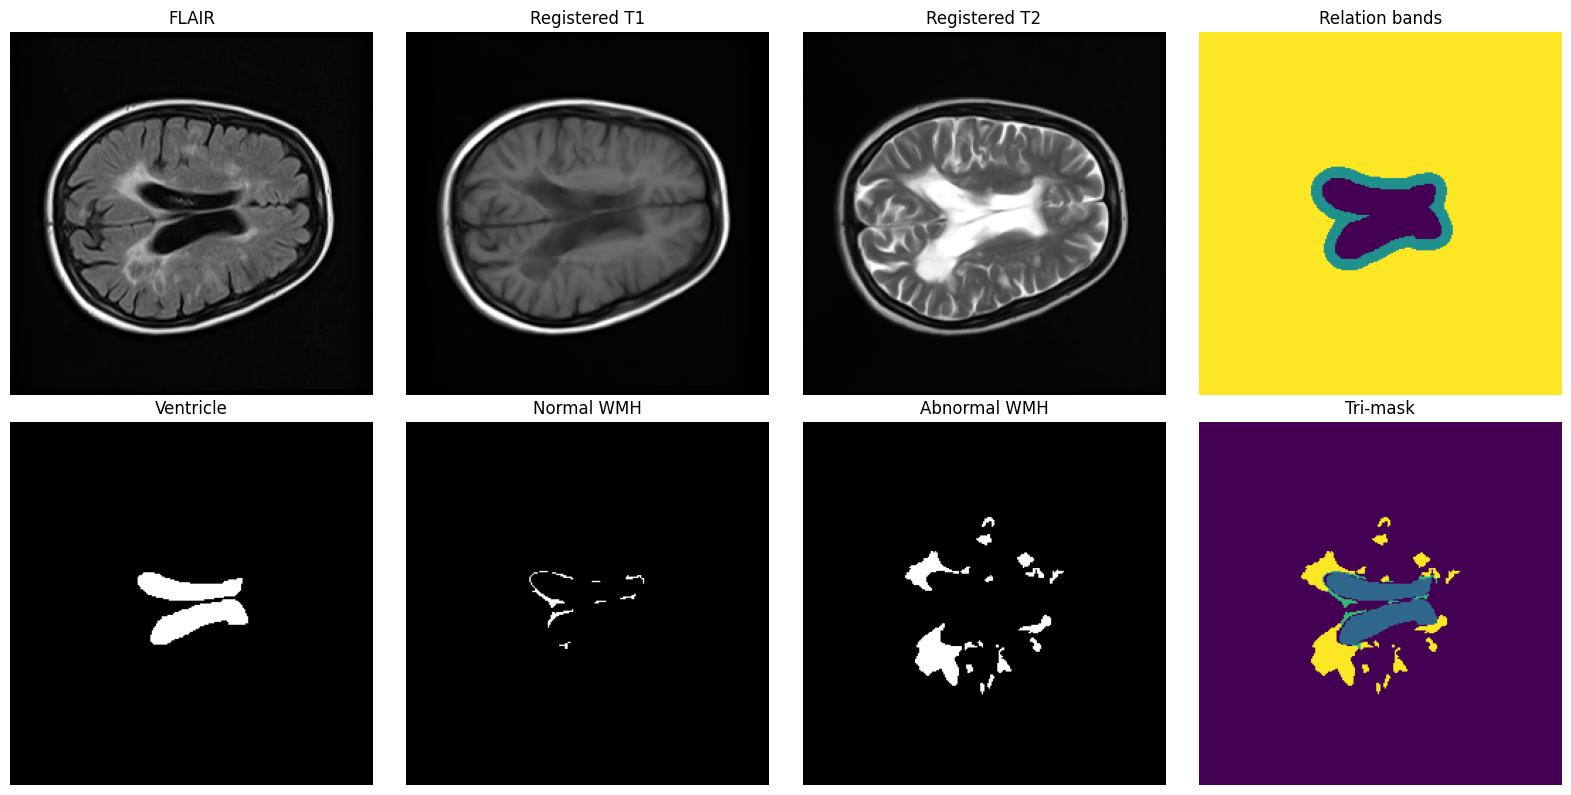

In [11]:
manifest_by_id = manifest.set_index("patient_id")
sample_pid = patient_stats.sort_values("abwmh_voxels", ascending=False).iloc[0].patient_id
row = manifest_by_id.loc[sample_pid]
flair, t1, t2 = [load_normalized_volume(row[k]) for k in ["flair", "t1", "t2"]]
target = compose_target(row)
bands = relation_band_volume(row.vent)
z = int(np.argmax((target == 3).sum(axis=(0, 1))))

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
for a, im, title in zip(
    ax.ravel(),
    [flair[:, :, z], t1[:, :, z], t2[:, :, z], bands[:, :, z],
     target[:, :, z] == 1, target[:, :, z] == 2, target[:, :, z] == 3, target[:, :, z]],
    ["FLAIR", "Registered T1", "Registered T2", "Relation bands",
     "Ventricle", "Normal WMH", "Abnormal WMH", "Tri-mask"]
):
    a.imshow(im, cmap="gray" if title != "Tri-mask" and title != "Relation bands" else "viridis")
    a.set_title(title)
    a.axis("off")
plt.tight_layout()
plt.show()

In [12]:
class MS3SEGVentiMorphDataset(Dataset):
    def __init__(
        self,
        manifest_df,
        patient_ids,
        augment=False,
        include_empty=True,
    ):
        self.manifest = manifest_df.set_index(
            "patient_id"
        )

        self.patient_ids = [
            str(value).zfill(
                3
            )
            for value in patient_ids
        ]

        self.augment = bool(
            augment
        )

        self.samples = []
        self.sample_weights = []
        self.sample_info = []

        for patient_id in self.patient_ids:
            row = self.manifest.loc[
                patient_id
            ]

            target = compose_target(
                row
            )

            for slice_index in range(
                target.shape[
                    2
                ]
            ):
                current_target = target[
                    :,
                    :,
                    slice_index,
                ]

                ventricle_pixels = int(
                    (
                        current_target
                        == 1
                    ).sum()
                )

                normal_pixels = int(
                    (
                        current_target
                        == 2
                    ).sum()
                )

                abnormal_pixels = int(
                    (
                        current_target
                        == 3
                    ).sum()
                )

                total_wmh_pixels = (
                    normal_pixels
                    + abnormal_pixels
                )

                if (
                    include_empty
                    or (
                        ventricle_pixels
                        + total_wmh_pixels
                    )
                    > 0
                ):
                    small_wmh = (
                        total_wmh_pixels
                        > 0
                        and total_wmh_pixels
                        <= 64
                    )

                    if small_wmh:
                        sample_weight = 2.5
                        group = "small_wmh"
                    elif total_wmh_pixels > 0:
                        sample_weight = 2.0
                        group = "wmh"
                    elif ventricle_pixels > 0:
                        sample_weight = 1.25
                        group = "ventricle_only"
                    else:
                        sample_weight = 1.0
                        group = "background"

                    self.samples.append(
                        (
                            patient_id,
                            slice_index,
                        )
                    )

                    self.sample_weights.append(
                        float(
                            sample_weight
                        )
                    )

                    self.sample_info.append({
                        "patient_id": patient_id,
                        "slice_index": slice_index,
                        "group": group,
                        "ventricle_pixels": ventricle_pixels,
                        "normal_pixels": normal_pixels,
                        "abnormal_pixels": abnormal_pixels,
                        "total_wmh_pixels": total_wmh_pixels,
                    })

    def __len__(self):
        return len(
            self.samples
        )

    @staticmethod
    def triplet(
        volume,
        slice_index,
    ):
        depth = volume.shape[
            2
        ]

        indices = [
            max(
                0,
                slice_index
                - 1,
            ),
            slice_index,
            min(
                depth
                - 1,
                slice_index
                + 1,
            ),
        ]

        return np.stack(
            [
                volume[
                    :,
                    :,
                    index,
                ]
                for index in indices
            ],
            axis=0,
        )

    def _augment(
        self,
        image,
        target,
        region,
    ):
        if random.random() < 0.5:
            image = torch.flip(
                image,
                dims=[
                    2,
                ],
            )

            target = torch.flip(
                target,
                dims=[
                    1,
                ],
            )

            region = torch.flip(
                region,
                dims=[
                    1,
                ],
            )

        if random.random() < 0.60:
            (
                angle,
                translate,
                scale,
                shear,
            ) = T.RandomAffine.get_params(
                degrees=(
                    -8.0,
                    8.0,
                ),
                translate=(
                    0.02,
                    0.02,
                ),
                scale_ranges=(
                    0.97,
                    1.03,
                ),
                shears=None,
                img_size=[
                    image.shape[
                        1
                    ],
                    image.shape[
                        2
                    ],
                ],
            )

            image = TF.affine(
                image,
                angle,
                translate,
                scale,
                shear,
                interpolation=(
                    InterpolationMode.BILINEAR
                ),
                fill=0.0,
            )

            target = TF.affine(
                target
                .unsqueeze(
                    0
                )
                .float(),
                angle,
                translate,
                scale,
                shear,
                interpolation=(
                    InterpolationMode.NEAREST
                ),
                fill=0.0,
            ).squeeze(
                0
            ).long()

            region = TF.affine(
                region
                .unsqueeze(
                    0
                )
                .float(),
                angle,
                translate,
                scale,
                shear,
                interpolation=(
                    InterpolationMode.NEAREST
                ),
                fill=2.0,
            ).squeeze(
                0
            ).long()

        for start in (
            0,
            3,
            6,
        ):
            modality = image[
                start:start
                + 3
            ]

            modality = (
                modality
                * random.uniform(
                    0.95,
                    1.05,
                )
                + random.uniform(
                    -0.05,
                    0.05,
                )
            )

            if random.random() < 0.15:
                modality = (
                    modality
                    + torch.randn_like(
                        modality
                    )
                    * 0.015
                )

            image[
                start:start
                + 3
            ] = modality

        return (
            image,
            target,
            region,
        )

    def __getitem__(
        self,
        index,
    ):
        (
            patient_id,
            slice_index,
        ) = self.samples[
            index
        ]

        row = self.manifest.loc[
            patient_id
        ]

        flair = load_normalized_volume(
            row.flair
        )

        t1 = load_normalized_volume(
            row.t1
        )

        t2 = load_normalized_volume(
            row.t2
        )

        image = np.concatenate(
            [
                self.triplet(
                    flair,
                    slice_index,
                ),
                self.triplet(
                    t1,
                    slice_index,
                ),
                self.triplet(
                    t2,
                    slice_index,
                ),
            ],
            axis=0,
        )

        target = compose_target(
            row
        )[
            :,
            :,
            slice_index,
        ]

        region = relation_band_volume(
            row.vent
        )[
            :,
            :,
            slice_index,
        ]

        image = torch.from_numpy(
            image.copy()
        ).float()

        target = torch.from_numpy(
            target.copy()
        ).long()

        region = torch.from_numpy(
            region.copy()
        ).long()

        if self.augment:
            (
                image,
                target,
                region,
            ) = self._augment(
                image,
                target,
                region,
            )

        return {
            "image": image,
            "target": target,
            "region_band": region,
            "patient_id": patient_id,
            "slice_index": slice_index,
        }

In [13]:
class ConvNormAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, stride=1, groups=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, stride=stride, padding=k//2, groups=groups, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.SiLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c1 = ConvNormAct(ch, ch)
        self.c2 = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1, bias=False),
                                nn.GroupNorm(min(8, ch), ch))
        self.act = nn.SiLU(inplace=True)
    def forward(self, x): return self.act(x + self.c2(self.c1(x)))

class SE(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        h = max(8, ch // r)
        self.net = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(ch, h, 1),
                                 nn.SiLU(inplace=True), nn.Conv2d(h, ch, 1), nn.Sigmoid())
    def forward(self, x): return x * self.net(x)

class ModalityStem(nn.Module):
    def __init__(self, out_ch):
        super().__init__()
        self.net = nn.Sequential(ConvNormAct(3, out_ch), ResidualBlock(out_ch), SE(out_ch))
    def forward(self, x): return self.net(x)

class ModalityGatedFusion(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(ch * 3, max(8, ch // 2)),
                                  nn.SiLU(inplace=True), nn.Linear(max(8, ch // 2), 3))
        self.refine = ResidualBlock(ch)
    def forward(self, f, t1, t2):
        pooled = torch.cat([F.adaptive_avg_pool2d(x, 1).flatten(1) for x in [f, t1, t2]], 1)
        w = torch.softmax(self.gate(pooled), 1)
        fused = w[:, 0, None, None, None] * f + w[:, 1, None, None, None] * t1 + w[:, 2, None, None, None] * t2
        return self.refine(fused), w

class DownBlock(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.net = nn.Sequential(ConvNormAct(i, o, stride=2), ResidualBlock(o))
    def forward(self, x): return self.net(x)

class UpBlock(nn.Module):
    def __init__(self, i, s, o):
        super().__init__()
        self.net = nn.Sequential(ConvNormAct(i + s, o), ResidualBlock(o))
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.net(torch.cat([x, skip], 1))

class AdaptiveAnisotropicContext(nn.Module):
    def __init__(self, ch):
        super().__init__()
        b = ch // 4
        self.reduce = ConvNormAct(ch, b, 1)
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv2d(b, b, 3, padding=d, dilation=d, groups=b, bias=False),
                          nn.GroupNorm(min(8, b), b), nn.SiLU(inplace=True))
            for d in (1, 2, 4, 6)
        ])
        self.mix = nn.Sequential(nn.Conv2d(b * 4, ch, 1, bias=False),
                                 nn.GroupNorm(min(8, ch), ch), nn.SiLU(inplace=True))
        self.se = SE(ch)
    def forward(self, x):
        r = self.reduce(x)
        y = self.se(self.mix(torch.cat([b(r) for b in self.branches], 1)))
        return x + y

In [14]:
class VentiMorphRefiner(nn.Module):
    def __init__(self, ch, mode: Literal["none", "vent", "distance", "directional"]):
        super().__init__()
        self.mode = mode
        self.vent_head = nn.Conv2d(ch, 1, 1)
        extras = {"none": 0, "vent": 1, "distance": 5, "directional": 9}[mode]
        self.orientation_head = nn.Conv2d(ch, 2, 1) if mode == "directional" else None
        self.refine = nn.Identity() if mode == "none" else nn.Sequential(
            ConvNormAct(ch + extras, ch), ResidualBlock(ch)
        )
        sx = torch.tensor([[-1.,0.,1.],[-2.,0.,2.],[-1.,0.,1.]]).view(1,1,3,3)
        sy = torch.tensor([[-1.,-2.,-1.],[0.,0.,0.],[1.,2.,1.]]).view(1,1,3,3)
        self.register_buffer("sobel_x", sx)
        self.register_buffer("sobel_y", sy)

    def forward(self, feat):
        v_logit = self.vent_head(feat)
        v = torch.sigmoid(v_logit)
        relation = {"vent_logits": v_logit, "vent_prob": v}
        if self.mode == "none":
            return feat, relation
        if self.mode == "vent":
            return feat + self.refine(torch.cat([feat, v], 1)), relation

        e1 = F.max_pool2d(v, 7, 1, 3)
        e2 = F.max_pool2d(v, 21, 1, 10)
        near = torch.clamp(e1 - v, 0, 1)
        mid = torch.clamp(e2 - e1, 0, 1)
        far = torch.clamp(1 - e2, 0, 1)
        dist = 0.2 * near + 0.6 * mid + far
        relation.update({"near": near, "mid": mid, "far": far, "soft_distance": dist})
        extras = [v, near, mid, far, dist]

        if self.mode == "directional":
            normal = torch.cat([F.conv2d(dist, self.sobel_x, padding=1),
                                F.conv2d(dist, self.sobel_y, padding=1)], 1)
            normal = F.normalize(normal, dim=1, eps=1e-6)
            orient = F.normalize(self.orientation_head(feat), dim=1, eps=1e-6)
            radial = torch.abs((normal * orient).sum(1, keepdim=True))
            tangential = 1 - radial
            relation.update({
                "normal_x": normal[:,0:1], "normal_y": normal[:,1:2],
                "orientation_x": orient[:,0:1], "orientation_y": orient[:,1:2],
                "radial": radial, "tangential": tangential,
            })
            extras += [normal[:,0:1], normal[:,1:2], radial, tangential]

        return feat + self.refine(torch.cat([feat] + extras, 1)), relation

class RelationConditionedPrototypeBank(nn.Module):
    def __init__(self, dim=32, temperature=0.1):
        super().__init__()
        self.temperature = temperature
        self.prototypes = nn.Parameter(F.normalize(torch.randn(2, 3, dim), dim=-1))

    def loss(self, embedding, target, region, max_samples=4096):
        feat = embedding.permute(0, 2, 3, 1)
        idx = ((target == 2) | (target == 3)).nonzero(as_tuple=False)
        if idx.numel() == 0:
            return embedding.sum() * 0
        if idx.shape[0] > max_samples:
            idx = idx[torch.randperm(idx.shape[0], device=idx.device)[:max_samples]]
        b, y, x = idx[:,0], idx[:,1], idx[:,2]
        f = F.normalize(feat[b, y, x], dim=1)
        label = (target[b, y, x] == 3).long()
        r = region[b, y, x].clamp(0, 2).long()
        p = F.normalize(self.prototypes, dim=-1)[:, r, :].permute(1, 0, 2)
        logits = torch.einsum("nd,ncd->nc", f, p) / self.temperature
        return F.cross_entropy(logits, label)

In [15]:
class VentiMorphRelNet(nn.Module):
    def __init__(self, base=24, num_classes=4, use_multimodal=True, use_context=True,
                 guidance_mode="directional", use_prototypes=True, use_uncertainty=True, emb_dim=32):
        super().__init__()
        self.use_multimodal = use_multimodal
        self.use_prototypes = use_prototypes
        self.flair_stem, self.t1_stem, self.t2_stem = [ModalityStem(base) for _ in range(3)]
        self.fusion = ModalityGatedFusion(base)

        self.e0 = nn.Sequential(ConvNormAct(base, 32), ResidualBlock(32))
        self.e1, self.e2, self.e3, self.e4 = DownBlock(32,64), DownBlock(64,128), DownBlock(128,192), DownBlock(192,256)
        self.context = AdaptiveAnisotropicContext(256) if use_context else ResidualBlock(256)
        self.drop = nn.Dropout2d(0.1)
        self.d3, self.d2, self.d1, self.d0 = UpBlock(256,192,192), UpBlock(192,128,128), UpBlock(128,64,64), UpBlock(64,32,32)
        self.mid_guide = VentiMorphRefiner(128, guidance_mode)
        self.final_guide = VentiMorphRefiner(32, guidance_mode)

        self.embedding = nn.Sequential(ConvNormAct(32, emb_dim), nn.Conv2d(emb_dim, emb_dim, 1))
        self.seg_head = nn.Conv2d(32, num_classes, 1)
        self.evidence_head = nn.Conv2d(32, num_classes, 1) if use_uncertainty else None
        self.prototype_bank = RelationConditionedPrototypeBank(emb_dim) if use_prototypes else None

    def forward(self, x):
        if x.ndim != 4 or x.shape[1] != 9:
            raise ValueError(f"Expected [B,9,H,W], got {tuple(x.shape)}")
        f = self.flair_stem(x[:,0:3])
        t1 = self.t1_stem(x[:,3:6]) if self.use_multimodal else torch.zeros_like(f)
        t2 = self.t2_stem(x[:,6:9]) if self.use_multimodal else torch.zeros_like(f)
        fused, weights = self.fusion(f, t1, t2)

        e0 = self.e0(fused); e1 = self.e1(e0); e2 = self.e2(e1); e3 = self.e3(e2)
        e4 = self.drop(self.context(self.e4(e3)))
        d3 = self.d3(e4, e3)
        d2, mid_rel = self.mid_guide(self.d2(d3, e2))
        d1 = self.d1(d2, e1)
        d0, final_rel = self.final_guide(self.d0(d1, e0))

        emb = self.embedding(d0)
        logits = self.seg_head(d0)
        evidence = F.softplus(self.evidence_head(d0)) if self.evidence_head is not None else None
        alpha = evidence + 1 if evidence is not None else None
        uncertainty = 4.0 / alpha.sum(1, keepdim=True) if alpha is not None else None
        return {
            "segmentation_logits": logits, "embedding": emb,
            "modality_weights": weights, "mid_relation": mid_rel,
            "final_relation": final_rel, "evidence": evidence,
            "alpha": alpha, "uncertainty": uncertainty,
        }

    def prototype_loss(self, out, target, region):
        if self.prototype_bank is None:
            return out["embedding"].sum() * 0
        return self.prototype_bank.loss(out["embedding"], target, region)

In [16]:
model = VentiMorphRelNet().to(DEVICE)
dummy = torch.randn(1, 9, 256, 256, device=DEVICE)
with torch.no_grad():
    out = model(dummy)
print("Segmentation:", out["segmentation_logits"].shape)
print("Uncertainty:", out["uncertainty"].shape)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
del dummy, out
torch.cuda.empty_cache()

Segmentation: torch.Size([1, 4, 256, 256])
Uncertainty: torch.Size([1, 1, 256, 256])
Parameters: 5974441


In [17]:
def soft_dice_loss(logits, target, eps=1e-6):
    probability = torch.softmax(logits, dim=1)[:, 1:]
    one_hot = (
        F.one_hot(target, num_classes=4)
        .permute(0, 3, 1, 2)
        .float()[:, 1:]
    )

    intersection = (probability * one_hot).sum((0, 2, 3))
    denominator = (
        probability.sum((0, 2, 3))
        + one_hot.sum((0, 2, 3))
    )

    return 1.0 - (
        (2.0 * intersection + eps)
        / (denominator + eps)
    ).mean()


def focal_tversky_class(
    logits,
    target,
    class_id,
    alpha=0.70,
    beta=0.30,
    gamma=0.75,
    eps=1e-6,
):
    probability = torch.softmax(logits, dim=1)[:, class_id]
    truth = (target == class_id).float()

    true_positive = (probability * truth).sum()
    false_positive = (
        probability * (1.0 - truth)
    ).sum()
    false_negative = (
        (1.0 - probability) * truth
    ).sum()

    tversky = (
        true_positive + eps
    ) / (
        true_positive
        + alpha * false_negative
        + beta * false_positive
        + eps
    )

    return (1.0 - tversky) ** gamma


def binary_dice_loss(probability, truth, eps=1e-6):
    return 1.0 - (
        2.0 * (probability * truth).sum() + eps
    ) / (
        probability.sum() + truth.sum() + eps
    )


def soft_boundary_map(probability, kernel_size=3):
    maximum = F.max_pool2d(
        probability,
        kernel_size,
        stride=1,
        padding=kernel_size // 2,
    )
    minimum = -F.max_pool2d(
        -probability,
        kernel_size,
        stride=1,
        padding=kernel_size // 2,
    )
    return torch.clamp(
        maximum - minimum,
        0.0,
        1.0,
    )


def boundary_loss(logits, target):
    probability = torch.softmax(logits, dim=1)
    losses = []

    for class_id in (2, 3):
        predicted_boundary = soft_boundary_map(
            probability[:, class_id:class_id + 1]
        )
        true_boundary = soft_boundary_map(
            (target == class_id).float().unsqueeze(1)
        )
        losses.append(
            F.l1_loss(
                predicted_boundary,
                true_boundary,
            )
        )

    return torch.stack(losses).mean()


def normal_abnormal_confusion_loss(
    logits,
    target,
    region_band,
    eps=1e-6,
):
    # Penalize class-3 probability inside true nWMH and class-2
    # probability inside true abWMH. Near-ventricle errors receive
    # slightly greater weight.
    probability = torch.softmax(logits, dim=1)
    normal_probability = probability[:, 2]
    abnormal_probability = probability[:, 3]

    normal_truth = (target == 2).float()
    abnormal_truth = (target == 3).float()

    anatomical_weight = torch.where(
        region_band == 0,
        torch.tensor(
            1.50,
            device=logits.device,
            dtype=logits.dtype,
        ),
        torch.where(
            region_band == 1,
            torch.tensor(
                1.20,
                device=logits.device,
                dtype=logits.dtype,
            ),
            torch.tensor(
                1.00,
                device=logits.device,
                dtype=logits.dtype,
            ),
        ),
    )

    normal_to_abnormal = (
        abnormal_probability
        * normal_truth
        * anatomical_weight
    ).sum() / (
        (normal_truth * anatomical_weight).sum()
        + eps
    )

    abnormal_to_normal = (
        normal_probability
        * abnormal_truth
        * anatomical_weight
    ).sum() / (
        (abnormal_truth * anatomical_weight).sum()
        + eps
    )

    return 0.5 * (
        normal_to_abnormal
        + abnormal_to_normal
    )


def linear_ramp(
    epoch,
    start_epoch,
    end_epoch,
    maximum,
):
    if epoch < start_epoch:
        return 0.0

    if epoch >= end_epoch:
        return float(maximum)

    progress = (
        epoch - start_epoch + 1
    ) / (
        end_epoch - start_epoch + 1
    )

    return float(maximum) * float(progress)


def dirichlet_kl(alpha):
    beta = torch.ones_like(alpha)

    sum_alpha = alpha.sum(
        dim=1,
        keepdim=True,
    )
    sum_beta = beta.sum(
        dim=1,
        keepdim=True,
    )

    log_beta_alpha = (
        torch.lgamma(sum_alpha)
        - torch.lgamma(alpha).sum(
            dim=1,
            keepdim=True,
        )
    )
    log_beta_beta = (
        torch.lgamma(beta).sum(
            dim=1,
            keepdim=True,
        )
        - torch.lgamma(sum_beta)
    )

    term = (
        (alpha - beta)
        * (
            torch.digamma(alpha)
            - torch.digamma(sum_alpha)
        )
    ).sum(
        dim=1,
        keepdim=True,
    )

    return (
        log_beta_alpha
        + log_beta_beta
        + term
    ).mean()


def evidential_loss(
    alpha,
    target,
    epoch,
    anneal_epochs=20,
):
    one_hot = (
        F.one_hot(
            target,
            num_classes=4,
        )
        .permute(0, 3, 1, 2)
        .float()
    )

    strength = alpha.sum(
        dim=1,
        keepdim=True,
    )

    negative_log_likelihood = (
        one_hot
        * (
            torch.digamma(strength)
            - torch.digamma(alpha)
        )
    ).sum(dim=1).mean()

    alpha_tilde = (
        one_hot
        + (1.0 - one_hot) * alpha
    )

    annealing = min(
        1.0,
        epoch / float(anneal_epochs),
    )

    return (
        negative_log_likelihood
        + 0.01
        * annealing
        * dirichlet_kl(alpha_tilde)
    )


class CompositeLoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()
        self.register_buffer(
            "class_weights",
            class_weights,
        )

    def forward(
        self,
        model,
        output,
        target,
        region,
        epoch,
    ):
        logits = output["segmentation_logits"]

        cross_entropy = F.cross_entropy(
            logits,
            target,
            weight=self.class_weights,
        )
        dice = soft_dice_loss(
            logits,
            target,
        )

        tversky_normal = focal_tversky_class(
            logits,
            target,
            class_id=2,
        )
        tversky_abnormal = focal_tversky_class(
            logits,
            target,
            class_id=3,
        )

        boundary = boundary_loss(
            logits,
            target,
        )
        confusion = normal_abnormal_confusion_loss(
            logits,
            target,
            region,
        )

        ventricle_truth = (
            target == 1
        ).float().unsqueeze(1)

        final_ventricle_logits = output[
            "final_relation"
        ]["vent_logits"]
        final_ventricle_probability = torch.sigmoid(
            final_ventricle_logits
        )

        middle_ventricle_logits = F.interpolate(
            output["mid_relation"]["vent_logits"],
            size=target.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        ventricle = (
            F.binary_cross_entropy_with_logits(
                final_ventricle_logits,
                ventricle_truth,
            )
            + binary_dice_loss(
                final_ventricle_probability,
                ventricle_truth,
            )
            + 0.5
            * F.binary_cross_entropy_with_logits(
                middle_ventricle_logits,
                ventricle_truth,
            )
        )

        prototype = model.prototype_loss(
            output,
            target,
            region,
        )

        if output["alpha"] is not None:
            uncertainty = evidential_loss(
                output["alpha"],
                target,
                epoch,
            )
        else:
            uncertainty = logits.sum() * 0.0

        normal_tversky_weight = linear_ramp(
            epoch,
            start_epoch=1,
            end_epoch=10,
            maximum=0.25,
        )
        confusion_weight = linear_ramp(
            epoch,
            start_epoch=11,
            end_epoch=20,
            maximum=0.05,
        )

        total = (
            cross_entropy
            + dice
            + normal_tversky_weight
            * tversky_normal
            + 0.50
            * tversky_abnormal
            + 0.30
            * ventricle
            + 0.20
            * boundary
            + confusion_weight
            * confusion
            + 0.10
            * prototype
            + 0.05
            * uncertainty
        )

        return {
            "total": total,
            "ce": cross_entropy.detach(),
            "dice": dice.detach(),
            "tversky_nwmh": tversky_normal.detach(),
            "tversky_abwmh": tversky_abnormal.detach(),
            "vent": ventricle.detach(),
            "boundary": boundary.detach(),
            "confusion": confusion.detach(),
            "prototype": prototype.detach(),
            "uncertainty": uncertainty.detach(),
            "nwmh_weight": torch.tensor(
                normal_tversky_weight,
                device=logits.device,
            ),
            "confusion_weight": torch.tensor(
                confusion_weight,
                device=logits.device,
            ),
        }

In [18]:
FOLD = 4
BATCH_SIZE = 4
NUM_WORKERS = 0

fold_train_ids = split_df[
    (
        split_df.fold
        == FOLD
    )
    & (
        split_df.role
        == "train"
    )
].patient_id.tolist()

fold_val_ids = split_df[
    (
        split_df.fold
        == FOLD
    )
    & (
        split_df.role
        == "val"
    )
].patient_id.tolist()

heldout_test_ids = split_df[
    split_df.role
    == "test"
].patient_id.tolist()


if len(fold_train_ids) != 64:
    raise ValueError(
        f"Fold 4 expected 64 training patients, found {len(fold_train_ids)}."
    )

if len(fold_val_ids) != 16:
    raise ValueError(
        f"Fold 4 expected 16 validation patients, found {len(fold_val_ids)}."
    )

if len(heldout_test_ids) != 20:
    raise ValueError(
        f"Expected 20 locked-test patients, found {len(heldout_test_ids)}."
    )

if set(fold_train_ids).intersection(fold_val_ids):
    raise RuntimeError(
        "Fold-4 train/validation leakage detected."
    )

if (
    set(fold_train_ids).intersection(heldout_test_ids)
    or set(fold_val_ids).intersection(heldout_test_ids)
):
    raise RuntimeError(
        "Locked-test leakage detected."
    )

print(
    "Fold-4 split safety check passed."
)


def compute_class_weights(
    patient_ids,
):
    table = manifest.set_index(
        "patient_id"
    )

    counts = np.zeros(
        4,
        dtype=np.int64,
    )

    for patient_id in patient_ids:
        counts += np.bincount(
            compose_target(
                table.loc[
                    patient_id
                ]
            ).ravel(),
            minlength=4,
        )

    frequency = (
        counts
        / counts.sum()
    )

    weights = (
        1.0
        / np.sqrt(
            frequency
            + 1e-12
        )
    )

    weights = (
        weights
        / weights.mean()
    )

    print(
        "Class counts:",
        counts,
    )

    print(
        "Class weights:",
        weights,
    )

    return torch.tensor(
        weights,
        dtype=torch.float32,
    )


class_weights = compute_class_weights(
    fold_train_ids
).to(
    DEVICE
)

train_ds = MS3SEGVentiMorphDataset(
    manifest,
    fold_train_ids,
    augment=True,
)

val_ds = MS3SEGVentiMorphDataset(
    manifest,
    fold_val_ids,
    augment=False,
)

sampler_generator = torch.Generator()
sampler_generator.manual_seed(
    SEED
)

sampler = WeightedRandomSampler(
    torch.as_tensor(
        train_ds.sample_weights,
        dtype=torch.double,
    ),
    num_samples=len(
        train_ds
    ),
    replacement=True,
    generator=sampler_generator,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
)

group_counts = pd.Series(
    [
        information[
            "group"
        ]
        for information
        in train_ds.sample_info
    ]
).value_counts()

print(
    "Train/validation/test patients:",
    len(
        fold_train_ids
    ),
    len(
        fold_val_ids
    ),
    len(
        heldout_test_ids
    ),
)

print(
    "Train/validation slices:",
    len(
        train_ds
    ),
    len(
        val_ds
    ),
)

print(
    "Stable loader: workers=0, moderate sampling, batch size=4."
)

display(
    group_counts.to_frame(
        "slice_count"
    )
)

Fold-4 split safety check passed.
Class counts: [82728516   330300    97662   139778]
Class weights: [0.05693221 0.90101372 1.65700143 1.38505264]
Train/validation/test patients: 64 16 20
Train/validation slices: 1271 316
Stable loader: workers=0, moderate sampling, batch size=4.


,slice_count
wmh,578
background,352
small_wmh,280
ventricle_only,61


## Stable DataLoader check

This verifies that batches can be loaded in the main process before full training starts.

In [19]:
test_batch = next(iter(train_loader))
print("Stable train batch image shape:", test_batch["image"].shape)
print("Stable train batch target shape:", test_batch["target"].shape)
print("DataLoader stability check passed.")
del test_batch
torch.cuda.empty_cache()

Stable train batch image shape: torch.Size([4, 9, 256, 256])
Stable train batch target shape: torch.Size([4, 256, 256])
DataLoader stability check passed.


In [20]:
@torch.no_grad()
def batch_cm(pred, target, k=4):
    pred, target = pred.reshape(-1), target.reshape(-1)
    idx = k * target + pred
    return torch.bincount(idx, minlength=k*k).reshape(k, k)

def cm_metrics(cm, eps=1e-6):
    cm = cm.float()
    tp = torch.diag(cm); fp = cm.sum(0)-tp; fn = cm.sum(1)-tp; tn = cm.sum()-tp-fp-fn
    return {
        "dice": ((2*tp+eps)/(2*tp+fp+fn+eps)).cpu().numpy(),
        "iou": ((tp+eps)/(tp+fp+fn+eps)).cpu().numpy(),
        "precision": ((tp+eps)/(tp+fp+eps)).cpu().numpy(),
        "recall": ((tp+eps)/(tp+fn+eps)).cpu().numpy(),
        "specificity": ((tn+eps)/(tn+fp+eps)).cpu().numpy(),
    }

@torch.no_grad()
def validate(model, loader, criterion, epoch):
    model.eval()
    total, cm = 0.0, torch.zeros((4,4), dtype=torch.long, device=DEVICE)
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["target"].to(DEVICE, non_blocking=True)
        r = batch["region_band"].to(DEVICE, non_blocking=True)
        out = model(x)
        loss = criterion(model, out, y, r, epoch)["total"]
        total += float(loss.item()) * x.size(0)
        cm += batch_cm(out["segmentation_logits"].argmax(1), y).to(DEVICE)
    m = cm_metrics(cm)
    m["loss"] = total / len(loader.dataset)
    m["mean_fg_dice"] = float(np.mean(m["dice"][1:]))
    return m

In [21]:
import shutil


@dataclass
class ExperimentConfig:
    epochs: int = 60
    lr: float = 1e-4
    weight_decay: float = 1e-4
    patience: int = 12
    min_improvement: float = 1e-4
    grad_clip: float = 2.0

    plateau_factor: float = 0.5
    plateau_patience: int = 3
    minimum_lr: float = 1e-6

    collapse_margin: float = 0.05
    collapse_patience: int = 2

    gradient_alarm_threshold: float = 300.0
    gradient_alarm_patience: int = 2

    rollback_lr_factor: float = 0.5
    max_rollbacks: int = 2

    transfer_every_epochs: int = 5

    base: int = 24
    use_multimodal: bool = True
    use_context: bool = True
    guidance_mode: str = "directional"
    use_prototypes: bool = True
    use_uncertainty: bool = True

    fold: int = 0
    seed: int = 42
    auto_resume: bool = True


def calculate_checkpoint_scores(
    ventricle_dice,
    normal_dice,
    abnormal_dice,
):
    foreground = np.asarray(
        [
            ventricle_dice,
            normal_dice,
            abnormal_dice,
        ],
        dtype=np.float64,
    )

    weighted = float(
        0.20
        * foreground[
            0
        ]
        + 0.40
        * foreground[
            1
        ]
        + 0.40
        * foreground[
            2
        ]
    )

    macro = float(
        foreground.mean()
    )

    balanced = float(
        macro
        - 0.25
        * foreground.std()
    )

    return {
        "weighted": weighted,
        "macro": macro,
        "balanced": balanced,
    }


def build_optimizer(
    model,
    config,
    learning_rate=None,
):
    return torch.optim.AdamW(
        model.parameters(),
        lr=(
            config.lr
            if learning_rate
            is None
            else float(
                learning_rate
            )
        ),
        weight_decay=config.weight_decay,
        betas=(
            0.9,
            0.99,
        ),
    )


def build_scheduler(
    optimizer,
    config,
):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config.plateau_factor,
        patience=config.plateau_patience,
        threshold=config.min_improvement,
        threshold_mode="abs",
        min_lr=config.minimum_lr,
    )


def save_training_state(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    config,
    epoch,
    history,
    best_scores,
    patience_counter,
    collapse_counter,
    gradient_alarm_counter,
    rollbacks_used,
):
    state = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "config": asdict(
            config
        ),
        "epoch": int(
            epoch
        ),
        "history": history,
        "best_scores": {
            key: float(
                value
            )
            for key, value
            in best_scores.items()
        },
        "patience_counter": int(
            patience_counter
        ),
        "collapse_counter": int(
            collapse_counter
        ),
        "gradient_alarm_counter": int(
            gradient_alarm_counter
        ),
        "rollbacks_used": int(
            rollbacks_used
        ),
        "torch_rng_state": torch.get_rng_state(),
        "numpy_rng_state": np.random.get_state(),
    }

    if torch.cuda.is_available():
        state[
            "cuda_rng_state_all"
        ] = torch.cuda.get_rng_state_all()

    torch.save(
        state,
        path,
    )


def _to_cpu_byte_tensor(
    state,
):
    """
    Convert a saved PyTorch RNG state to the exact representation required by
    torch.set_rng_state and torch.cuda.set_rng_state_all.
    """
    if state is None:
        return None

    if isinstance(
        state,
        torch.Tensor,
    ):
        return (
            state
            .detach()
            .to(
                device="cpu",
                dtype=torch.uint8,
            )
            .contiguous()
        )

    if isinstance(
        state,
        np.ndarray,
    ):
        return (
            torch.from_numpy(
                state
            )
            .to(
                dtype=torch.uint8
            )
            .cpu()
            .contiguous()
        )

    if isinstance(
        state,
        (
            list,
            tuple,
        ),
    ):
        return torch.tensor(
            state,
            dtype=torch.uint8,
            device="cpu",
        ).contiguous()

    return None


def restore_rng_state(
    checkpoint,
):
    """
    Restore RNG states without allowing an incompatible old RNG object to
    prevent checkpoint resumption.
    """
    torch_state = _to_cpu_byte_tensor(
        checkpoint.get(
            "torch_rng_state"
        )
    )

    if torch_state is not None:
        try:
            torch.set_rng_state(
                torch_state
            )

            print(
                "CPU torch RNG state restored."
            )

        except Exception as error:
            warnings.warn(
                "CPU torch RNG state could not be restored; "
                f"continuing from the model/optimizer checkpoint. {error}"
            )

    numpy_state = checkpoint.get(
        "numpy_rng_state"
    )

    if numpy_state is not None:
        try:
            np.random.set_state(
                numpy_state
            )

            print(
                "NumPy RNG state restored."
            )

        except Exception as error:
            warnings.warn(
                "NumPy RNG state could not be restored; "
                f"continuing with the current seeded state. {error}"
            )

    if torch.cuda.is_available():
        cuda_states = checkpoint.get(
            "cuda_rng_state_all"
        )

        if cuda_states is not None:
            try:
                if isinstance(
                    cuda_states,
                    torch.Tensor,
                ):
                    cuda_states = [
                        cuda_states
                    ]

                converted_states = [
                    _to_cpu_byte_tensor(
                        state
                    )
                    for state in cuda_states
                ]

                converted_states = [
                    state
                    for state in converted_states
                    if state is not None
                ]

                if converted_states:
                    visible_gpu_count = (
                        torch.cuda.device_count()
                    )

                    if len(
                        converted_states
                    ) < visible_gpu_count:
                        converted_states.extend(
                            [
                                converted_states[
                                    -1
                                ].clone()
                                for _ in range(
                                    visible_gpu_count
                                    - len(
                                        converted_states
                                    )
                                )
                            ]
                        )

                    torch.cuda.set_rng_state_all(
                        converted_states[
                            :visible_gpu_count
                        ]
                    )

                    print(
                        "CUDA RNG state restored."
                    )

            except Exception as error:
                warnings.warn(
                    "CUDA RNG state could not be restored; "
                    f"continuing from the model/optimizer checkpoint. {error}"
                )


def create_transfer_archive(
    run_directory,
    epoch,
    reason,
):
    transfer_directory = Path(
        "/kaggle/working/MS3SEG_V27_FOLD4_TRANSFER"
    )

    if transfer_directory.exists():
        shutil.rmtree(
            transfer_directory
        )

    transfer_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    useful_files = [
        run_directory
        / "best_model.pt",
        run_directory
        / "best_weighted_model.pt",
        run_directory
        / "best_nwmh_model.pt",
        run_directory
        / "last_checkpoint.pt",
        run_directory
        / "emergency_checkpoint.pt",
        run_directory
        / "history.csv",
        OUTPUT_DIR
        / "patient_level_5fold_split.csv",
        OUTPUT_DIR
        / "patient_manifest.csv",
        OUTPUT_DIR
        / "integrity_audit.csv",
    ]

    copied_files = []

    for source_file in useful_files:
        if source_file.exists():
            destination = (
                transfer_directory
                / source_file.name
            )

            shutil.copy2(
                source_file,
                destination,
            )

            copied_files.append(
                source_file.name
            )

    metadata = {
        "model": "VentiMorph-RelNet-v2.7-fresh-stable",
        "epoch": int(
            epoch
        ),
        "reason": str(
            reason
        ),
        "run_directory": str(
            run_directory
        ),
        "copied_files": copied_files,
        "locked_test_evaluated": False,
    }

    with open(
        transfer_directory
        / "transfer_metadata.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            metadata,
            file,
            indent=2,
        )

    archive_path = shutil.make_archive(
        "/kaggle/working/MS3SEG_V27_FOLD4_TRANSFER",
        "zip",
        root_dir=transfer_directory,
    )

    print(
        "Updated transfer ZIP:",
        archive_path,
    )

    return Path(
        archive_path
    )


def train_experiment(
    config,
    run_name,
):
    seed_everything(
        config.seed
    )

    run_directory = (
        OUTPUT_DIR
        / run_name
    )

    run_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    last_checkpoint_path = (
        run_directory
        / "last_checkpoint.pt"
    )

    best_checkpoint_path = (
        run_directory
        / "best_model.pt"
    )

    best_weighted_checkpoint_path = (
        run_directory
        / "best_weighted_model.pt"
    )

    best_nwmh_checkpoint_path = (
        run_directory
        / "best_nwmh_model.pt"
    )

    emergency_checkpoint_path = (
        run_directory
        / "emergency_checkpoint.pt"
    )

    history_path = (
        run_directory
        / "history.csv"
    )

    model = VentiMorphRelNet(
        base=config.base,
        use_multimodal=config.use_multimodal,
        use_context=config.use_context,
        guidance_mode=config.guidance_mode,
        use_prototypes=config.use_prototypes,
        use_uncertainty=config.use_uncertainty,
    ).to(
        DEVICE
    )

    criterion = CompositeLoss(
        class_weights
    ).to(
        DEVICE
    )

    optimizer = build_optimizer(
        model,
        config,
    )

    scheduler = build_scheduler(
        optimizer,
        config,
    )

    amp_enabled = (
        DEVICE.type
        == "cuda"
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=amp_enabled,
    )

    start_epoch = 1

    best_scores = {
        "balanced": float(
            "-inf"
        ),
        "weighted": float(
            "-inf"
        ),
        "normal": float(
            "-inf"
        ),
    }

    patience_counter = 0
    collapse_counter = 0
    gradient_alarm_counter = 0
    rollbacks_used = 0
    history = []

    if (
        config.auto_resume
        and last_checkpoint_path.exists()
    ):
        checkpoint = torch.load(
            last_checkpoint_path,
            map_location=DEVICE,
            weights_only=False,
        )

        model.load_state_dict(
            checkpoint[
                "model_state"
            ]
        )

        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state"
            ]
        )

        scheduler.load_state_dict(
            checkpoint[
                "scheduler_state"
            ]
        )

        scaler.load_state_dict(
            checkpoint[
                "scaler_state"
            ]
        )

        start_epoch = int(
            checkpoint.get(
                "epoch",
                0,
            )
        ) + 1

        history = list(
            checkpoint.get(
                "history",
                [],
            )
        )

        best_scores.update(
            checkpoint.get(
                "best_scores",
                {},
            )
        )

        patience_counter = int(
            checkpoint.get(
                "patience_counter",
                0,
            )
        )

        collapse_counter = int(
            checkpoint.get(
                "collapse_counter",
                0,
            )
        )

        gradient_alarm_counter = int(
            checkpoint.get(
                "gradient_alarm_counter",
                0,
            )
        )

        rollbacks_used = int(
            checkpoint.get(
                "rollbacks_used",
                0,
            )
        )

        restore_rng_state(
            checkpoint
        )

        print(
            "Resuming from:",
            last_checkpoint_path,
        )

        print(
            "Next epoch:",
            start_epoch,
        )

    else:
        print(
            "Starting fresh stable V2.7 training from scratch."
        )

    current_epoch = (
        start_epoch
    )

    try:
        for epoch in range(
            start_epoch,
            config.epochs
            + 1,
        ):
            current_epoch = epoch
            model.train()

            running_loss = 0.0
            processed_samples = 0
            skipped_batches = 0
            gradient_norm_sum = 0.0
            gradient_steps = 0

            for batch in train_loader:
                image = batch[
                    "image"
                ].to(
                    DEVICE,
                    non_blocking=False,
                )

                target = batch[
                    "target"
                ].to(
                    DEVICE,
                    non_blocking=False,
                )

                region = batch[
                    "region_band"
                ].to(
                    DEVICE,
                    non_blocking=False,
                )

                optimizer.zero_grad(
                    set_to_none=True,
                )

                with torch.amp.autocast(
                    device_type="cuda",
                    enabled=amp_enabled,
                ):
                    output = model(
                        image
                    )

                    losses = criterion(
                        model,
                        output,
                        target,
                        region,
                        epoch,
                    )

                    total_loss = losses[
                        "total"
                    ]

                if not torch.isfinite(
                    total_loss
                ):
                    skipped_batches += 1
                    optimizer.zero_grad(
                        set_to_none=True,
                    )
                    scaler.update()
                    continue

                scaler.scale(
                    total_loss
                ).backward()

                scaler.unscale_(
                    optimizer
                )

                gradient_norm = (
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        config.grad_clip,
                    )
                )

                if not torch.isfinite(
                    gradient_norm
                ):
                    skipped_batches += 1
                    optimizer.zero_grad(
                        set_to_none=True,
                    )
                    scaler.update()
                    continue

                scaler.step(
                    optimizer
                )

                scaler.update()

                running_loss += (
                    float(
                        total_loss.item()
                    )
                    * image.size(
                        0
                    )
                )

                processed_samples += (
                    image.size(
                        0
                    )
                )

                gradient_norm_sum += float(
                    gradient_norm.item()
                )

                gradient_steps += 1

            if processed_samples == 0:
                raise RuntimeError(
                    "No finite training batch completed."
                )

            validation = validate(
                model,
                val_loader,
                criterion,
                epoch,
            )

            ventricle_dice = float(
                validation[
                    "dice"
                ][
                    1
                ]
            )

            normal_dice = float(
                validation[
                    "dice"
                ][
                    2
                ]
            )

            abnormal_dice = float(
                validation[
                    "dice"
                ][
                    3
                ]
            )

            scores = calculate_checkpoint_scores(
                ventricle_dice,
                normal_dice,
                abnormal_dice,
            )

            primary_score = scores[
                "balanced"
            ]

            previous_best = best_scores[
                "balanced"
            ]

            improved_primary = (
                primary_score
                > previous_best
                + config.min_improvement
            )

            mean_gradient_norm = (
                gradient_norm_sum
                / max(
                    1,
                    gradient_steps,
                )
            )

            validation_collapse = (
                np.isfinite(
                    previous_best
                )
                and primary_score
                < (
                    previous_best
                    - config.collapse_margin
                )
            )

            gradient_alarm = (
                mean_gradient_norm
                > config.gradient_alarm_threshold
            )

            gradient_alarm_counter = (
                gradient_alarm_counter
                + 1
                if gradient_alarm
                else 0
            )

            instability = (
                validation_collapse
                or gradient_alarm_counter
                >= config.gradient_alarm_patience
            )

            collapse_counter = (
                collapse_counter
                + 1
                if instability
                else 0
            )

            history_row = {
                "epoch": epoch,
                "train_loss": (
                    running_loss
                    / processed_samples
                ),
                "val_loss": validation[
                    "loss"
                ],
                "val_mean_fg_dice": validation[
                    "mean_fg_dice"
                ],
                "val_dice_vent": ventricle_dice,
                "val_dice_nwmh": normal_dice,
                "val_dice_abwmh": abnormal_dice,
                "val_weighted_score": scores[
                    "weighted"
                ],
                "val_macro_score": scores[
                    "macro"
                ],
                "val_balanced_score": scores[
                    "balanced"
                ],
                "mean_gradient_norm": mean_gradient_norm,
                "gradient_alarm": bool(
                    gradient_alarm
                ),
                "gradient_alarm_counter": int(
                    gradient_alarm_counter
                ),
                "collapse_counter": int(
                    collapse_counter
                ),
                "skipped_batches": int(
                    skipped_batches
                ),
                "rollbacks_used": int(
                    rollbacks_used
                ),
                "lr": optimizer.param_groups[
                    0
                ][
                    "lr"
                ],
            }

            history.append(
                history_row
            )

            print(
                f"E{epoch:03d} "
                f"train={history_row['train_loss']:.4f} "
                f"val={history_row['val_loss']:.4f} "
                f"FG={history_row['val_mean_fg_dice']:.4f} "
                f"V={ventricle_dice:.4f} "
                f"n={normal_dice:.4f} "
                f"ab={abnormal_dice:.4f} "
                f"W={scores['weighted']:.4f} "
                f"B={scores['balanced']:.4f} "
                f"grad={mean_gradient_norm:.2f} "
                f"gAlarm={gradient_alarm_counter} "
                f"collapse={collapse_counter} "
                f"lr={history_row['lr']:.7f}"
            )

            primary_improved_this_epoch = False

            if improved_primary:
                best_scores[
                    "balanced"
                ] = primary_score

                patience_counter = 0
                collapse_counter = 0
                gradient_alarm_counter = 0
                primary_improved_this_epoch = True

                torch.save({
                    "model_state": model.state_dict(),
                    "config": asdict(
                        config
                    ),
                    "best_balanced_score": primary_score,
                    "best_weighted_score": scores[
                        "weighted"
                    ],
                    "best_macro_score": scores[
                        "macro"
                    ],
                    "best_val_mean_fg_dice": validation[
                        "mean_fg_dice"
                    ],
                    "best_val_dice_vent": ventricle_dice,
                    "best_val_dice_nwmh": normal_dice,
                    "best_val_dice_abwmh": abnormal_dice,
                    "best_epoch": epoch,
                }, best_checkpoint_path)

            else:
                patience_counter += 1

            if (
                scores[
                    "weighted"
                ]
                > best_scores[
                    "weighted"
                ]
                + config.min_improvement
            ):
                best_scores[
                    "weighted"
                ] = scores[
                    "weighted"
                ]

                torch.save({
                    "model_state": model.state_dict(),
                    "config": asdict(
                        config
                    ),
                    "best_weighted_score": scores[
                        "weighted"
                    ],
                    "best_balanced_score": scores[
                        "balanced"
                    ],
                    "best_val_dice_vent": ventricle_dice,
                    "best_val_dice_nwmh": normal_dice,
                    "best_val_dice_abwmh": abnormal_dice,
                    "best_epoch": epoch,
                }, best_weighted_checkpoint_path)

            if (
                normal_dice
                > best_scores[
                    "normal"
                ]
                + config.min_improvement
            ):
                best_scores[
                    "normal"
                ] = normal_dice

                torch.save({
                    "model_state": model.state_dict(),
                    "config": asdict(
                        config
                    ),
                    "best_val_dice_nwmh": normal_dice,
                    "best_epoch": epoch,
                }, best_nwmh_checkpoint_path)

            rolled_back = False

            if (
                collapse_counter
                >= config.collapse_patience
            ):
                if (
                    rollbacks_used
                    >= config.max_rollbacks
                ):
                    print(
                        "Maximum rollback count reached. "
                        "Stopping and preserving best_model.pt."
                    )
                    break

                if not best_checkpoint_path.exists():
                    raise FileNotFoundError(
                        "Instability occurred before a best checkpoint existed."
                    )

                best_checkpoint = torch.load(
                    best_checkpoint_path,
                    map_location=DEVICE,
                    weights_only=False,
                )

                model.load_state_dict(
                    best_checkpoint[
                        "model_state"
                    ]
                )

                old_learning_rate = float(
                    optimizer.param_groups[
                        0
                    ][
                        "lr"
                    ]
                )

                new_learning_rate = max(
                    config.minimum_lr,
                    old_learning_rate
                    * config.rollback_lr_factor,
                )

                optimizer = build_optimizer(
                    model,
                    config,
                    learning_rate=new_learning_rate,
                )

                scheduler = build_scheduler(
                    optimizer,
                    config,
                )

                scaler = torch.amp.GradScaler(
                    "cuda",
                    enabled=amp_enabled,
                )

                rollbacks_used += 1
                collapse_counter = 0
                gradient_alarm_counter = 0
                patience_counter = 0
                rolled_back = True

                print(
                    "Instability confirmed."
                )

                print(
                    "Restored:",
                    best_checkpoint_path,
                )

                print(
                    "Learning rate:",
                    old_learning_rate,
                    "->",
                    new_learning_rate,
                )

            if not rolled_back:
                scheduler.step(
                    primary_score
                )

            pd.DataFrame(
                history
            ).to_csv(
                history_path,
                index=False,
            )

            save_training_state(
                last_checkpoint_path,
                model,
                optimizer,
                scheduler,
                scaler,
                config,
                epoch,
                history,
                best_scores,
                patience_counter,
                collapse_counter,
                gradient_alarm_counter,
                rollbacks_used,
            )

            print(
                "Saved resumable checkpoint:",
                last_checkpoint_path,
            )

            if (
                primary_improved_this_epoch
                or epoch
                % config.transfer_every_epochs
                == 0
            ):
                create_transfer_archive(
                    run_directory,
                    epoch,
                    reason=(
                        "best_improvement"
                        if primary_improved_this_epoch
                        else "periodic_backup"
                    ),
                )

            if (
                patience_counter
                >= config.patience
            ):
                print(
                    "Early stopping at epoch",
                    epoch,
                )
                break

    except KeyboardInterrupt:
        save_training_state(
            emergency_checkpoint_path,
            model,
            optimizer,
            scheduler,
            scaler,
            config,
            current_epoch
            - 1,
            history,
            best_scores,
            patience_counter,
            collapse_counter,
            gradient_alarm_counter,
            rollbacks_used,
        )

        create_transfer_archive(
            run_directory,
            current_epoch
            - 1,
            reason="manual_interruption",
        )

        print(
            "\nTraining interrupted safely."
        )

        print(
            "Emergency checkpoint:",
            emergency_checkpoint_path,
        )

        print(
            "Download:",
            "/kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip",
        )

        raise

    if not best_checkpoint_path.exists():
        raise FileNotFoundError(
            "No best_model.pt was created."
        )

    best_checkpoint = torch.load(
        best_checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(
        best_checkpoint[
            "model_state"
        ]
    )

    create_transfer_archive(
        run_directory,
        (
            history[
                -1
            ][
                "epoch"
            ]
            if history
            else 0
        ),
        reason="run_complete",
    )

    return (
        model,
        pd.DataFrame(
            history
        ),
        run_directory,
    )

## Training control

Run the ten-epoch conservative pilot first. It uses the same stable
optimization pipeline as the successful baseline and introduces only
small, controlled WMH-supervision changes.

Do not start the full 80-epoch run until the pilot shows that ventricle,
normal-WMH, and abnormal-WMH Dice values are all learning.

## One-batch forward/backward dry run

This cell checks every loss term before starting the three-epoch smoke test.
All printed values must be finite.

In [22]:
dry_model = VentiMorphRelNet(
    base=24,
    use_multimodal=True,
    use_context=True,
    guidance_mode="directional",
    use_prototypes=True,
    use_uncertainty=True,
).to(DEVICE)

dry_criterion = CompositeLoss(class_weights).to(DEVICE)
dry_optimizer = torch.optim.AdamW(dry_model.parameters(), lr=3e-4)

dry_batch = next(iter(train_loader))
dry_x = dry_batch["image"].to(DEVICE, non_blocking=True)
dry_y = dry_batch["target"].to(DEVICE, non_blocking=True)
dry_r = dry_batch["region_band"].to(DEVICE, non_blocking=True)

dry_optimizer.zero_grad(set_to_none=True)

amp_enabled = DEVICE.type == "cuda"
with torch.amp.autocast(device_type="cuda", enabled=amp_enabled):
    dry_out = dry_model(dry_x)
    dry_losses = dry_criterion(
        dry_model,
        dry_out,
        dry_y,
        dry_r,
        epoch=1,
    )

for loss_name, loss_value in dry_losses.items():
    numeric_value = float(loss_value.detach().cpu())
    print(f"{loss_name}: {numeric_value:.6f}")
    if not np.isfinite(numeric_value):
        raise FloatingPointError(
            f"Non-finite loss detected: {loss_name}={numeric_value}"
        )

dry_losses["total"].backward()
torch.nn.utils.clip_grad_norm_(dry_model.parameters(), 5.0)
dry_optimizer.step()

print("One-batch forward/backward dry run completed successfully.")

del dry_model, dry_criterion, dry_optimizer
del dry_batch, dry_x, dry_y, dry_r, dry_out, dry_losses
gc.collect()
torch.cuda.empty_cache()

total: 3.847850
ce: 1.590916
dice: 0.997612
tversky_nwmh: 1.000000
tversky_abwmh: 0.991139
vent: 1.879437
boundary: 0.065122
confusion: 0.021703
prototype: 0.776660
uncertainty: 1.684602
nwmh_weight: 0.025000
confusion_weight: 0.000000
One-batch forward/backward dry run completed successfully.


In [23]:
RUN_FOLD1_TRAINING = True

RUN_NAME = "v27_fresh_stable_fold4"

pilot_config = ExperimentConfig(
    epochs=10,
    lr=1e-4,
    weight_decay=1e-4,
    patience=10,
    grad_clip=2.0,
    plateau_factor=0.5,
    plateau_patience=3,
    minimum_lr=1e-6,
    collapse_margin=0.05,
    collapse_patience=2,
    gradient_alarm_threshold=300.0,
    gradient_alarm_patience=2,
    rollback_lr_factor=0.5,
    max_rollbacks=2,
    transfer_every_epochs=5,
    base=24,
    use_multimodal=True,
    use_context=True,
    guidance_mode="directional",
    use_prototypes=True,
    use_uncertainty=True,
    fold=FOLD,
    seed=SEED,
    auto_resume=True,
)

full_config = ExperimentConfig(
    epochs=60,
    lr=1e-4,
    weight_decay=1e-4,
    patience=12,
    grad_clip=2.0,
    plateau_factor=0.5,
    plateau_patience=3,
    minimum_lr=1e-6,
    collapse_margin=0.05,
    collapse_patience=2,
    gradient_alarm_threshold=300.0,
    gradient_alarm_patience=2,
    rollback_lr_factor=0.5,
    max_rollbacks=2,
    transfer_every_epochs=5,
    base=24,
    use_multimodal=True,
    use_context=True,
    guidance_mode="directional",
    use_prototypes=True,
    use_uncertainty=True,
    fold=FOLD,
    seed=SEED,
    auto_resume=True,
)

if (
    RUN_FOLD1_TRAINING
    and not GPU_COMPATIBLE
):
    raise RuntimeError(
        "Fold-4 training requires a compatible CUDA GPU. "
        "Select a T4 GPU in Kaggle Settings, restart the session, "
        "and Run All."
    )

if not RUN_FOLD1_TRAINING:
    print(
        "Fold-4 training is disabled."
    )

else:
    run_directory = (
        OUTPUT_DIR / RUN_NAME
    )

    last_checkpoint_path = (
        run_directory
        / "last_checkpoint.pt"
    )

    existing_epoch = -1

    if last_checkpoint_path.exists():
        existing_checkpoint = torch.load(
            last_checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )

        existing_epoch = int(
            existing_checkpoint.get(
                "epoch",
                -1,
            )
        )

        existing_fold = int(
            existing_checkpoint.get(
                "config",
                {},
            ).get(
                "fold",
                -999,
            )
        )

        if existing_fold != FOLD:
            raise RuntimeError(
                "A checkpoint from another fold was found "
                "inside the Fold-4 run directory."
            )

        print(
            "Existing Fold-4 checkpoint detected at epoch:",
            existing_epoch,
        )

    if existing_epoch < 10:
        print(
            "\n"
            + "=" * 80
        )

        print(
            "STAGE 1: FOLD-1 TEN-EPOCH STABILITY PILOT"
        )

        print(
            "=" * 80
        )

        (
            trained_model,
            history,
            run_dir,
        ) = train_experiment(
            pilot_config,
            RUN_NAME,
        )

        print(
            "Fold-4 pilot stage completed."
        )

        del trained_model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    pilot_history_path = (
        OUTPUT_DIR
        / RUN_NAME
        / "history.csv"
    )

    if not pilot_history_path.exists():
        raise FileNotFoundError(
            "Fold-4 pilot history was not created."
        )

    pilot_history = pd.read_csv(
        pilot_history_path
    )

    first_ten_epochs = (
        pilot_history.loc[
            pilot_history.epoch <= 10
        ]
        .copy()
    )

    if len(first_ten_epochs) == 0:
        raise RuntimeError(
            "No Fold-4 pilot epochs were found."
        )

    numerical_stability_pass = bool(
        np.isfinite(
            first_ten_epochs[
                [
                    "train_loss",
                    "val_loss",
                    "val_dice_vent",
                    "val_dice_nwmh",
                    "val_dice_abwmh",
                    "mean_gradient_norm",
                ]
            ].to_numpy()
        ).all()
        and first_ten_epochs[
            "skipped_batches"
        ].max()
        < max(
            1,
            math.ceil(
                len(train_ds)
                / BATCH_SIZE
            )
            * 0.10,
        )
        and first_ten_epochs[
            "mean_gradient_norm"
        ].max()
        < 300.0
    )

    print(
        "Fold-4 pilot numerical stability:",
        numerical_stability_pass,
    )

    print(
        "Best Fold-4 pilot epoch:"
    )

    display(
        first_ten_epochs.loc[
            first_ten_epochs[
                "val_balanced_score"
            ].idxmax()
        ].to_frame(
            name="value"
        )
    )

    if not numerical_stability_pass:
        raise RuntimeError(
            "Fold-4 pilot failed the numerical stability gate. "
            "Full training has been stopped."
        )

    print(
        "\n"
        + "=" * 80
    )

    print(
        "STAGE 2: CONTINUE SAME FOLD-1 RUN TO MAXIMUM 60 EPOCHS"
    )

    print(
        "=" * 80
    )

    (
        trained_model,
        history,
        run_dir,
    ) = train_experiment(
        full_config,
        RUN_NAME,
    )

    print(
        "Fold-4 full training stage completed."
    )

    print(
        "Download immediately:",
        "/kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip",
    )

    if len(history) > 0:
        display(
            history.tail(15)
        )


STAGE 1: FOLD-1 TEN-EPOCH STABILITY PILOT
Starting fresh stable V2.7 training from scratch.
E001 train=2.1840 val=1.9034 FG=0.4530 V=0.6253 n=0.2938 ab=0.4399 W=0.4186 B=0.4191 grad=165.54 gAlarm=0 collapse=0 lr=0.0001000
Saved resumable checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/last_checkpoint.pt
Updated transfer ZIP: /kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip
E002 train=1.6786 val=1.7068 FG=0.5505 V=0.6268 n=0.4124 ab=0.6122 W=0.5352 B=0.5260 grad=53.31 gAlarm=0 collapse=0 lr=0.0001000
Saved resumable checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/last_checkpoint.pt
Updated transfer ZIP: /kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip
E003 train=1.4453 val=1.6356 FG=0.6117 V=0.7104 n=0.4646 ab=0.6601 W=0.5920 B=0.5852 grad=41.43 gAlarm=0 collapse=0 lr=0.0001000
Saved resumable checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/last_checkpoint.pt
Updated transfer ZIP: /kaggle/worki

,value
epoch,7
train_loss,1.285064
val_loss,1.590972
val_mean_fg_dice,0.675118
val_dice_vent,0.77859
val_dice_nwmh,0.524195
val_dice_abwmh,0.722569
val_weighted_score,0.654423
val_macro_score,0.675118
val_balanced_score,0.647832



STAGE 2: CONTINUE SAME FOLD-1 RUN TO MAXIMUM 60 EPOCHS
CPU torch RNG state restored.
NumPy RNG state restored.
CUDA RNG state restored.
Resuming from: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/last_checkpoint.pt
Next epoch: 11
E011 train=1.2338 val=1.6352 FG=0.6980 V=0.8176 n=0.5483 ab=0.7281 W=0.6741 B=0.6700 grad=62.87 gAlarm=0 collapse=0 lr=0.0001000
Saved resumable checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/last_checkpoint.pt
Updated transfer ZIP: /kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip
E012 train=1.1951 val=1.5025 FG=0.6359 V=0.7819 n=0.4508 ab=0.6751 W=0.6067 B=0.6014 grad=111.51 gAlarm=0 collapse=1 lr=0.0001000
Saved resumable checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/last_checkpoint.pt
E013 train=1.2093 val=1.5753 FG=0.6512 V=0.6717 n=0.5631 ab=0.7190 W=0.6471 B=0.6349 grad=218.75 gAlarm=0 collapse=0 lr=0.0001000
Saved resumable checkpoint: /kaggle/working/ventimorph_v

,epoch,train_loss,val_loss,val_mean_fg_dice,val_dice_vent,val_dice_nwmh,val_dice_abwmh,val_weighted_score,val_macro_score,val_balanced_score,mean_gradient_norm,gradient_alarm,gradient_alarm_counter,collapse_counter,skipped_batches,rollbacks_used,lr
34,35,1.068975,1.500135,0.730225,0.832118,0.605179,0.753378,0.709847,0.730225,0.706704,229.114290,False,0,0,0,0,0.000025
35,36,1.027933,1.456144,0.727200,0.837929,0.586179,0.757492,0.705054,0.727200,0.700954,323.200990,True,1,0,1,0,0.000013
36,37,1.031119,1.495024,0.726031,0.839185,0.598680,0.740227,0.703400,0.726031,0.701356,289.619815,False,0,0,1,0,0.000013
37,38,1.038001,1.415824,0.740496,0.850167,0.611244,0.760075,0.718561,0.740496,0.715866,447.404063,True,1,0,0,0,0.000013
38,39,1.026251,1.418779,0.739387,0.846500,0.610365,0.761295,0.717964,0.739387,0.714977,256.768762,False,0,0,0,0,0.000013
39,40,1.049795,1.421644,0.737575,0.847021,0.607102,0.758601,0.715685,0.737574,0.712807,563.662211,True,1,0,0,0,0.000013
40,41,1.043692,1.439005,0.732603,0.835290,0.615846,0.746674,0.712066,0.732603,0.710068,313.860262,True,2,1,0,0,0.000013
41,42,1.065506,1.456016,0.727667,0.828991,0.598687,0.755322,0.707402,0.727667,0.703659,546.817301,True,3,2,0,0,0.000013
42,43,0.985658,1.426006,0.745067,0.851024,0.616333,0.767844,0.723876,0.745067,0.720778,440.412481,True,1,0,17,1,0.000006
43,44,1.006795,1.404620,0.741120,0.842234,0.620669,0.760455,0.720897,0.741120,0.718249,317.884140,True,1,0,1,1,0.000006


## Inspect training history

This cell plots loss and class-wise validation Dice for whichever run was just completed.

,epoch,train_loss,val_loss,val_mean_fg_dice,val_dice_vent,val_dice_nwmh,val_dice_abwmh,val_weighted_score,val_macro_score,val_balanced_score,mean_gradient_norm,gradient_alarm,gradient_alarm_counter,collapse_counter,skipped_batches,rollbacks_used,lr
39,40,1.049795,1.421644,0.737575,0.847021,0.607102,0.758601,0.715685,0.737574,0.712807,563.662211,True,1,0,0,0,0.000013
40,41,1.043692,1.439005,0.732603,0.835290,0.615846,0.746674,0.712066,0.732603,0.710068,313.860262,True,2,1,0,0,0.000013
41,42,1.065506,1.456016,0.727667,0.828991,0.598687,0.755322,0.707402,0.727667,0.703659,546.817301,True,3,2,0,0,0.000013
42,43,0.985658,1.426006,0.745067,0.851024,0.616333,0.767844,0.723876,0.745067,0.720778,440.412481,True,1,0,17,1,0.000006
43,44,1.006795,1.404620,0.741120,0.842234,0.620669,0.760455,0.720897,0.741120,0.718249,317.884140,True,1,0,1,1,0.000006
44,45,1.014138,1.417481,0.740543,0.844032,0.616648,0.760949,0.719845,0.740543,0.717057,328.280345,True,2,1,0,1,0.000006
45,46,1.025116,1.440211,0.739087,0.838213,0.617573,0.761475,0.719262,0.739087,0.716223,452.012552,True,3,2,0,1,0.000006
46,47,1.011329,1.429375,0.741356,0.846180,0.611459,0.766429,0.720391,0.741356,0.716994,394.416127,True,1,0,17,2,0.000003
47,48,1.010968,1.423636,0.741461,0.848238,0.611379,0.764765,0.720105,0.741461,0.716938,403.508596,True,2,1,1,2,0.000003
48,49,1.007071,1.433730,0.738476,0.848005,0.605074,0.762348,0.716570,0.738476,0.713325,315.837203,True,3,2,0,2,0.000003


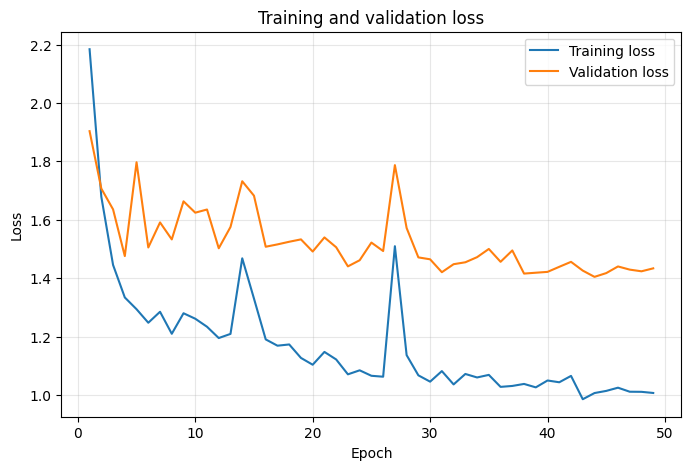

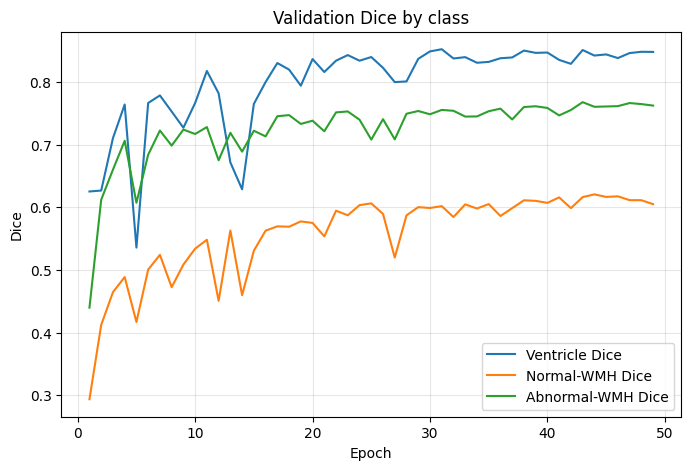

In [24]:
if "history" in globals() and len(history) > 0:
    display(history.tail(10))

    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["train_loss"], label="Training loss")
    plt.plot(history["epoch"], history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["val_dice_vent"], label="Ventricle Dice")
    plt.plot(history["epoch"], history["val_dice_nwmh"], label="Normal-WMH Dice")
    plt.plot(history["epoch"], history["val_dice_abwmh"], label="Abnormal-WMH Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title("Validation Dice by class")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No training history is available yet.")

## Pilot decision check

This cell checks whether all three foreground classes are learning.
These thresholds are for pipeline validation only, not publication targets.

In [25]:
if (
    "history"
    in globals()
    and len(
        history
    )
    > 0
):
    required_columns = {
        "val_balanced_score",
        "val_weighted_score",
        "val_dice_vent",
        "val_dice_nwmh",
        "val_dice_abwmh",
        "mean_gradient_norm",
        "skipped_batches",
    }

    missing_columns = (
        required_columns
        - set(
            history.columns
        )
    )

    if missing_columns:
        raise KeyError(
            "Pilot history is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    best_balanced_index = history[
        "val_balanced_score"
    ].idxmax()

    best_weighted_index = history[
        "val_weighted_score"
    ].idxmax()

    best_normal_index = history[
        "val_dice_nwmh"
    ].idxmax()

    best_balanced = history.loc[
        best_balanced_index
    ]

    best_weighted = history.loc[
        best_weighted_index
    ]

    best_normal = history.loc[
        best_normal_index
    ]

    print(
        "Best balanced-score pilot epoch:"
    )

    display(
        best_balanced.to_frame(
            name="value"
        )
    )

    print(
        "Best weighted-score pilot epoch:"
    )

    display(
        best_weighted.to_frame(
            name="value"
        )
    )

    print(
        "Best normal-WMH pilot epoch:"
    )

    display(
        best_normal.to_frame(
            name="value"
        )
    )

    total_training_batches = int(
        math.ceil(
            len(
                train_ds
            )
            / BATCH_SIZE
        )
    )

    maximum_skipped_rate = float(
        (
            history[
                "skipped_batches"
            ]
            / max(
                1,
                total_training_batches,
            )
        ).max()
    )

    maximum_gradient_norm = float(
        history[
            "mean_gradient_norm"
        ].max()
    )

    final_epoch = history.iloc[
        -1
    ]

    pilot_pass = bool(
        best_balanced[
            "val_dice_vent"
        ]
        >= 0.70
        and best_balanced[
            "val_dice_nwmh"
        ]
        >= 0.50
        and best_balanced[
            "val_dice_abwmh"
        ]
        >= 0.68
        and best_balanced[
            "val_balanced_score"
        ]
        >= 0.63
        and maximum_gradient_norm
        < 300.0
        and maximum_skipped_rate
        < 0.10
    )

    print(
        "Maximum pre-clipping mean gradient norm:",
        maximum_gradient_norm,
    )

    print(
        "Maximum skipped-batch rate:",
        maximum_skipped_rate,
    )

    print(
        "Final pilot balanced score:",
        float(
            final_epoch[
                "val_balanced_score"
            ]
        ),
    )

    print(
        "Pilot stability and learning check:",
        pilot_pass,
    )

    if pilot_pass:
        print(
            "The pilot is stable and learning all foreground classes. "
            "Download the transfer ZIP, then continue the same run by setting "
            "RUN_STABLE_PILOT=False and RUN_FULL_TRAINING=True."
        )

    else:
        print(
            "Do not start full training. Inspect the weakest class, "
            "skipped batches, and gradient history first."
        )

else:
    print(
        "No pilot history is available yet."
    )

Best balanced-score pilot epoch:


,value
epoch,43
train_loss,0.985658
val_loss,1.426006
val_mean_fg_dice,0.745067
val_dice_vent,0.851024
val_dice_nwmh,0.616333
val_dice_abwmh,0.767844
val_weighted_score,0.723876
val_macro_score,0.745067
val_balanced_score,0.720778


Best weighted-score pilot epoch:


,value
epoch,43
train_loss,0.985658
val_loss,1.426006
val_mean_fg_dice,0.745067
val_dice_vent,0.851024
val_dice_nwmh,0.616333
val_dice_abwmh,0.767844
val_weighted_score,0.723876
val_macro_score,0.745067
val_balanced_score,0.720778


Best normal-WMH pilot epoch:


,value
epoch,44
train_loss,1.006795
val_loss,1.40462
val_mean_fg_dice,0.74112
val_dice_vent,0.842234
val_dice_nwmh,0.620669
val_dice_abwmh,0.760455
val_weighted_score,0.720897
val_macro_score,0.74112
val_balanced_score,0.718249


Maximum pre-clipping mean gradient norm: 563.6622107733721
Maximum skipped-batch rate: 0.05345911949685535
Final pilot balanced score: 0.7133251216428167
Pilot stability and learning check: False
Do not start full training. Inspect the weakest class, skipped batches, and gradient history first.


## Verify and summarize the full-training checkpoint

This cell confirms that the best checkpoint and training history were saved successfully.

In [26]:
run_directory = (
    OUTPUT_DIR
    / RUN_NAME
)

best_checkpoint = (
    run_directory
    / "best_model.pt"
)

best_weighted_checkpoint = (
    run_directory
    / "best_weighted_model.pt"
)

best_nwmh_checkpoint = (
    run_directory
    / "best_nwmh_model.pt"
)

last_checkpoint = (
    run_directory
    / "last_checkpoint.pt"
)

history_path = (
    run_directory
    / "history.csv"
)

print(
    "Best balanced checkpoint:",
    best_checkpoint,
    "| exists:",
    best_checkpoint.exists(),
)

print(
    "Best weighted checkpoint:",
    best_weighted_checkpoint,
    "| exists:",
    best_weighted_checkpoint.exists(),
)

print(
    "Best normal-WMH checkpoint:",
    best_nwmh_checkpoint,
    "| exists:",
    best_nwmh_checkpoint.exists(),
)

print(
    "Latest resumable checkpoint:",
    last_checkpoint,
    "| exists:",
    last_checkpoint.exists(),
)

print(
    "Transfer ZIP:",
    "/kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip",
)

if history_path.exists():
    saved_history = pd.read_csv(
        history_path
    )

    print(
        "Best balanced-score epoch:"
    )

    display(
        saved_history.loc[
            saved_history[
                "val_balanced_score"
            ].idxmax()
        ].to_frame(
            name="value"
        )
    )

    print(
        "Best weighted-score epoch:"
    )

    display(
        saved_history.loc[
            saved_history[
                "val_weighted_score"
            ].idxmax()
        ].to_frame(
            name="value"
        )
    )

Best balanced checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/best_model.pt | exists: True
Best weighted checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/best_weighted_model.pt | exists: True
Best normal-WMH checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/best_nwmh_model.pt | exists: True
Latest resumable checkpoint: /kaggle/working/ventimorph_v27_fold4_training/v27_fresh_stable_fold4/last_checkpoint.pt | exists: True
Transfer ZIP: /kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip
Best balanced-score epoch:


,value
epoch,43
train_loss,0.985658
val_loss,1.426006
val_mean_fg_dice,0.745067
val_dice_vent,0.851024
val_dice_nwmh,0.616333
val_dice_abwmh,0.767844
val_weighted_score,0.723876
val_macro_score,0.745067
val_balanced_score,0.720778


Best weighted-score epoch:


,value
epoch,43
train_loss,0.985658
val_loss,1.426006
val_mean_fg_dice,0.745067
val_dice_vent,0.851024
val_dice_nwmh,0.616333
val_dice_abwmh,0.767844
val_weighted_score,0.723876
val_macro_score,0.745067
val_balanced_score,0.720778


## Save the trained model before leaving Kaggle

This packages the main checkpoint, the best-normal-WMH checkpoint, and
`history.csv` into one downloadable ZIP file.

In [27]:
transfer_zip = Path(
    "/kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip"
)

if transfer_zip.exists():
    print(
        "Transfer archive is ready:",
        transfer_zip,
    )

    print(
        "Download it now or save a Kaggle notebook version with outputs."
    )

else:
    print(
        "Transfer archive does not exist yet. "
        "At least one complete epoch must finish."
    )

Transfer archive is ready: /kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip
Download it now or save a Kaggle notebook version with outputs.


In [28]:
def build_input_slice(row, z):
    vols = [load_normalized_volume(row[k]) for k in ["flair", "t1", "t2"]]
    x = np.concatenate([MS3SEGVentiMorphDataset.triplet(v, z) for v in vols], axis=0)
    return torch.from_numpy(x.copy()).float()

@torch.no_grad()
def predict_patient(model, pid):
    model.eval()
    row = manifest_by_id.loc[str(pid).zfill(3)]
    target = compose_target(row)
    pred = np.zeros_like(target, dtype=np.uint8)
    uncertainty = np.zeros_like(target, dtype=np.float32)
    for z in range(target.shape[2]):
        out = model(build_input_slice(row, z).unsqueeze(0).to(DEVICE))
        pred[:, :, z] = out["segmentation_logits"].argmax(1).squeeze().cpu().numpy().astype(np.uint8)
        if out["uncertainty"] is not None:
            uncertainty[:, :, z] = out["uncertainty"].squeeze().cpu().numpy()
    return pred, target, uncertainty

In [29]:
def dice_binary(p, y, eps=1e-6):
    p, y = p.astype(bool), y.astype(bool)
    den = p.sum() + y.sum()
    return 1.0 if den == 0 else float((2*(p&y).sum()+eps)/(den+eps))

def iou_binary(p, y, eps=1e-6):
    p, y = p.astype(bool), y.astype(bool)
    u = (p|y).sum()
    return 1.0 if u == 0 else float(((p&y).sum()+eps)/(u+eps))

def hd95_binary(p, y, spacing):
    p, y = p.astype(bool), y.astype(bool)
    if not p.any() and not y.any(): return 0.0
    if not p.any() or not y.any(): return np.nan
    ps = np.logical_xor(p, ndimage.binary_erosion(p))
    ys = np.logical_xor(y, ndimage.binary_erosion(y))
    dt_y = ndimage.distance_transform_edt(~ys, sampling=spacing)
    dt_p = ndimage.distance_transform_edt(~ps, sampling=spacing)
    return float(np.percentile(np.concatenate([dt_y[ps], dt_p[ys]]), 95))

def lesion_metrics(p, y, min_voxels=3):
    st = ndimage.generate_binary_structure(3, 2)
    pl, pn = ndimage.label(p.astype(bool), structure=st)
    yl, yn = ndimage.label(y.astype(bool), structure=st)
    pc = [pl == i for i in range(1, pn+1) if (pl == i).sum() >= min_voxels]
    yc = [yl == i for i in range(1, yn+1) if (yl == i).sum() >= min_voxels]
    dt = sum(any((a&b).any() for b in pc) for a in yc)
    mp = sum(any((a&b).any() for b in yc) for a in pc)
    sens = dt/len(yc) if yc else 1.0
    prec = mp/len(pc) if pc else (1.0 if not yc else 0.0)
    f1 = 2*prec*sens/(prec+sens+1e-12)
    return {"lesion_sensitivity": sens, "lesion_precision": prec, "lesion_f1": f1,
            "true_lesions": len(yc), "pred_lesions": len(pc),
            "false_positive_lesions": max(0, len(pc)-mp)}

def periventricular_fp_rate(pred_ab, true_ab, vent, spacing_xy, max_mm=10.0):
    dist = np.zeros_like(vent, dtype=np.float32)
    for z in range(vent.shape[2]):
        dist[:, :, z] = ndimage.distance_transform_edt(~vent[:, :, z].astype(bool), sampling=spacing_xy)
    peri = (dist <= max_mm) & (~vent.astype(bool))
    fp = pred_ab & (~true_ab) & peri
    return float(fp.sum() / max(1, int((pred_ab & peri).sum())))

def evaluate_patients(model, ids, name):
    rows = []
    for pid in ids:
        pred, target, unc = predict_patient(model, pid)
        row = manifest_by_id.loc[pid]
        spacing = tuple(float(v) for v in nib.load(row.flair, mmap=True).header.get_zooms()[:3])
        result = {"patient_id": pid, "split": name}
        for c, n in [(1, "vent"), (2, "nwmh"), (3, "abwmh")]:
            result[f"dice_{n}"] = dice_binary(pred == c, target == c)
            result[f"iou_{n}"] = iou_binary(pred == c, target == c)
            result[f"hd95_{n}_mm"] = hd95_binary(pred == c, target == c, spacing)
        result.update({f"abwmh_{k}": v for k, v in lesion_metrics(pred == 3, target == 3).items()})
        result["periventricular_fp_rate"] = periventricular_fp_rate(
            pred == 3, target == 3, load_binary_mask(row.vent).astype(bool), spacing[:2]
        )
        err = pred != target
        result["mean_uncertainty"] = float(unc.mean())
        result["mean_uncertainty_error"] = float(unc[err].mean()) if err.any() else 0.0
        result["mean_uncertainty_correct"] = float(unc[~err].mean()) if (~err).any() else np.nan
        rows.append(result)
        print("Evaluated", pid)
    df = pd.DataFrame(rows)
    df.to_csv(OUTPUT_DIR / f"{name}_patient_metrics.csv", index=False)
    return df

In [30]:
RUN_TEST_EVALUATION = False
CHECKPOINT_PATH = OUTPUT_DIR / RUN_NAME / "best_model.pt"
if RUN_TEST_EVALUATION and not GPU_COMPATIBLE:
    raise RuntimeError(
        "RUN_TEST_EVALUATION requires a compatible CUDA GPU. Select T4 or another "
        "supported Kaggle GPU, restart the session, and Run All."
    )

if RUN_TEST_EVALUATION:
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    cfg = ckpt["config"]
    test_model = VentiMorphRelNet(
        base=cfg["base"], use_multimodal=cfg["use_multimodal"],
        use_context=cfg["use_context"], guidance_mode=cfg["guidance_mode"],
        use_prototypes=cfg["use_prototypes"], use_uncertainty=cfg["use_uncertainty"]
    ).to(DEVICE)
    test_model.load_state_dict(ckpt["model_state"])
    test_results = evaluate_patients(test_model, heldout_test_ids, "locked_test")
    display(test_results.describe())

In [31]:
ABLATIONS = {
    "A0_flair_2p5d": ExperimentConfig(use_multimodal=False, use_context=False, guidance_mode="none", use_prototypes=False, use_uncertainty=False),
    "A1_multimodal": ExperimentConfig(use_context=False, guidance_mode="none", use_prototypes=False, use_uncertainty=False),
    "A2_context": ExperimentConfig(guidance_mode="none", use_prototypes=False, use_uncertainty=False),
    "A3_vent_aux": ExperimentConfig(guidance_mode="vent", use_prototypes=False, use_uncertainty=False),
    "A4_distance": ExperimentConfig(guidance_mode="distance", use_prototypes=False, use_uncertainty=False),
    "A5_directional": ExperimentConfig(guidance_mode="directional", use_prototypes=False, use_uncertainty=False),
    "A6_prototypes": ExperimentConfig(guidance_mode="directional", use_prototypes=True, use_uncertainty=False),
    "A7_full": ExperimentConfig(),
}

RUN_ABLATIONS = False
if RUN_ABLATIONS and not GPU_COMPATIBLE:
    raise RuntimeError(
        "RUN_ABLATIONS requires a compatible CUDA GPU. Select T4 or another "
        "supported Kaggle GPU, restart the session, and Run All."
    )

if RUN_ABLATIONS:
    summary = []
    for name, cfg in ABLATIONS.items():
        print("="*80, "\n", name)
        m, h, d = train_experiment(cfg, name)
        vr = evaluate_patients(m, fold_val_ids, f"{name}_validation")
        summary.append({
            "experiment": name,
            "dice_vent": vr.dice_vent.mean(),
            "dice_nwmh": vr.dice_nwmh.mean(),
            "dice_abwmh": vr.dice_abwmh.mean(),
            "hd95_abwmh_mm": vr.hd95_abwmh_mm.mean(),
            "lesion_f1": vr.abwmh_lesion_f1.mean(),
            "periventricular_fp_rate": vr.periventricular_fp_rate.mean(),
        })
        del m
        gc.collect()
        torch.cuda.empty_cache()
    pd.DataFrame(summary).to_csv(OUTPUT_DIR / "ablation_summary.csv", index=False)
    display(pd.DataFrame(summary))

In [32]:
@torch.no_grad()
def visualize_prediction(model, pid, z=None):
    model.eval()
    row = manifest_by_id.loc[str(pid).zfill(3)]
    target = compose_target(row)
    flair = load_normalized_volume(row.flair)
    if z is None:
        z = int(np.argmax((target == 3).sum((0,1))))
    out = model(build_input_slice(row, z).unsqueeze(0).to(DEVICE))
    pred = out["segmentation_logits"].argmax(1).squeeze().cpu().numpy()
    vent = out["final_relation"]["vent_prob"].squeeze().cpu().numpy()
    radial = out["final_relation"].get("radial")
    radial = radial.squeeze().cpu().numpy() if radial is not None else np.zeros_like(vent)
    unc = out["uncertainty"].squeeze().cpu().numpy() if out["uncertainty"] is not None else np.zeros_like(vent)
    abp = torch.softmax(out["segmentation_logits"], 1)[:,3].squeeze().cpu().numpy()
    error = pred != target[:, :, z]

    fig, ax = plt.subplots(2, 4, figsize=(16,8))
    ims = [flair[:,:,z], target[:,:,z], pred, error, vent, radial, unc, abp]
    titles = ["FLAIR", "Ground truth", "Prediction", "Error", "Ventricle probability",
              "Radial alignment", "Uncertainty", "abWMH probability"]
    for a, im, title in zip(ax.ravel(), ims, titles):
        a.imshow(im, cmap="gray" if title not in ["Ground truth", "Prediction"] else "viridis")
        a.set_title(title)
        a.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"qualitative_{pid}_{z}.png", dpi=250, bbox_inches="tight")
    plt.show()

In [33]:
metadata = {
    "model": "VentiMorph-RelNet-v2.7-fold4",
    "dataset_root": str(DATA_ROOT),
    "patients": int(len(manifest)),
    "input": "9-channel multimodal 2.5D FLAIR/T1/T2",
    "classes": {"0": "background", "1": "ventricle", "2": "normal_WMH", "3": "abnormal_WMH"},
    "primary_modules": [
        "predicted ventricle-normalized directional morphology",
        "relation-conditioned normal/abnormal WMH prototype bank",
    ],
    "split": "80 development patients with 5-fold CV and 20 locked test patients, unless official split is confirmed",
    "seed": SEED,
}
with open(OUTPUT_DIR / "experiment_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(json.dumps(metadata, indent=2))

{
  "model": "VentiMorph-RelNet-v2.7-fold4",
  "dataset_root": "/kaggle/input/datasets/saifsamiul/ms3seg/MS3SEG",
  "patients": 100,
  "input": "9-channel multimodal 2.5D FLAIR/T1/T2",
  "classes": {
    "0": "background",
    "1": "ventricle",
    "2": "normal_WMH",
    "3": "abnormal_WMH"
  },
  "primary_modules": [
    "predicted ventricle-normalized directional morphology",
    "relation-conditioned normal/abnormal WMH prototype bank"
  ],
  "split": "80 development patients with 5-fold CV and 20 locked test patients, unless official split is confirmed",
  "seed": 42
}


## Run order on the new Kaggle account

1. Add the same MS3SEG dataset.
2. Select a T4 GPU.
3. Keep:
   `RUN_STABLE_PILOT=True`,
   `RUN_FULL_TRAINING=False`,
   `RUN_TEST_EVALUATION=False`.
4. Run All.
5. Download `MS3SEG_V27_FOLD4_TRANSFER.zip`.
6. Check that the ten pilot epochs are stable.
7. Change to:
   `RUN_STABLE_PILOT=False`,
   `RUN_FULL_TRAINING=True`.
8. Run All again. It resumes from epoch 11.
9. Download the transfer ZIP periodically and after completion.
10. Do not enable locked-test evaluation during model development.

## After Fold-4 training finishes

Download:

`/kaggle/working/MS3SEG_V27_FOLD4_TRANSFER.zip`

Also save the executed Kaggle notebook version.

Do **not** evaluate the locked-test set. The next step is Fold-4
validation evaluation using `best_model.pt`, followed by the same
already-frozen calibration configuration.